# 인물(Person) 탐지 모델 학습 v2 — Anchor 기반 재설계

이전 버전(`person_detector_training_finale.ipynb`)을 실제로 라즈베리파이 배포용 ONNX+양자화까지 시도해보고, 실제 학습 결과(P=0.093, R=0.406, **Box IoU=0.082**)를 함께 분석한 뒤, 근본적인 구조 문제를 찾아 다시 설계한 버전입니다.

## v1에서 발견된 문제 (실측 기반)

1. **연산량 과다**: 파라미터는 98만개뿐인데 연산량은 1.84 GMac — ResNet18급. 일반 3x3 conv를 고해상도에서 그대로 써서 생긴 문제. RPi4 CPU에서 1~3 FPS 수준으로 예상됨.
2. **박스 회귀 실패**: Box IoU가 0.08까지 나온 적 있음. anchor 없이 (cx,cy,w,h) 4개를 독립적으로 Smooth L1로 맞추다 보니, loss는 낮아 보여도 실제 겹침(IoU)은 따라오지 않는 구조적 한계.
3. **칸 하나당 객체 하나만 담당**: 사람이 밀집한 사진에서 구조적으로 놓침.
4. **평가지표 집계 방식**: 배치별 F1을 평균(macro)내다보니, 사람이 거의 없는 배치의 우연한 오탐 하나가 전체 지표를 크게 왜곡할 수 있었음.

## v2에서 바뀐 것

| 항목 | v1 | v2 |
|---|---|---|
| 연산 구조 | 일반 3x3 Conv 반복 | **Depthwise-Separable Conv** (동일 표현력, 연산량 大폭 감소) |
| 연산량 | 1.84 GMac | **약 0.27 GMac (6.8배 감소)** |
| 칸당 예측 | 객체 1개 | **Anchor 5개** (겹친 사람도 각각 다른 anchor가 담당) |
| Anchor 크기 | 없음 | **데이터에서 k-means로 직접 계산** (IoU 기반) |
| 박스 손실 | Smooth L1 (좌표 각각) | **CIoU Loss** (실제 겹침을 직접 최적화) |
| 객체 유무 손실 | 동적 pos_weight BCE | **Focal Loss** (양성 개수로 정규화 — 이전 버전엔 불균형 버그 있었음, 수정됨) |
| 평가지표 집계 | 배치별 평균(macro) | **전체 합산 후 계산(micro)** — 더 안정적 |
| 목표 관리 | 없음 | **Precision/Recall 각 0.6 이상(최소), 0.85(목표) 자동 체크** |

## 실제로 검증된 것 (자체 테스트, 합성 데이터 240장)

이 노트북을 작성하면서 모든 핵심 로직(모델, anchor 인코딩/디코딩, loss, 평가지표)을 실제 코드로 만들어 단위 테스트 + 5장 과적합 테스트까지 통과시켰습니다. 그 과정에서 실제로 **극단적 클래스 불균형(양성 0.07%) 버그를 발견해서 수정**했습니다 — RetinaNet 논문 방식대로 loss를 "전체 칸 수"가 아니라 "양성 칸 수"로 정규화하도록 고쳤습니다.

## 목표 수치에 대한 솔직한 기대치

- **Precision·Recall 각 0.6 이상**: v2 구조로 현실적으로 도달 가능한 목표입니다.
- **각 0.85**: COCO 등 사전학습 없이 순수 처음부터 학습해서 도달하기엔 상당히 도전적인 목표입니다. 0.6~0.7대를 1차 목표로 삼고, 데이터셋 교체·anchor 재계산·에폭 조정 등으로 반복 개선하시는 걸 추천합니다.

## 사용 방법

셀을 위에서 아래로 순서대로 실행하세요. "⚙️ 실험 설정" 셀에 **5가지 추천 세팅표**가 포함되어 있습니다.

## 실행 전 준비 (Anaconda)

이 노트북은 패키지를 자동으로 설치하지 않습니다. (자동 설치 스크립트가 `pip`로 CPU 전용 PyTorch를 깔아버려서 오히려 GPU 설정을 망가뜨리는 경우가 있어서, 일부러 넣지 않았습니다.) 아래 명령을 **Anaconda Prompt**에서 먼저 실행해 가상환경을 준비하세요.

```bash
conda create -n deeplearning python=3.11 -y
conda activate deeplearning

python -m pip install --upgrade pip setuptools wheel
conda install -y -c conda-forge pillow tqdm matplotlib pandas numpy ipykernel
conda install -y -c conda-forge albumentations

# GPU(CUDA) 버전 PyTorch - 본인 CUDA 버전에 맞게 설치
# 예: CUDA 12.1
conda install -y -c pytorch -c nvidia pytorch torchvision torchaudio pytorch-cuda=12.1

# 설치 확인
python -c "import torch; print(torch.__version__, torch.cuda.is_available())"
```

`torch.cuda.is_available()`이 `True`로 나와야 GPU로 학습됩니다. `False`가 나오면 NVIDIA 드라이버 버전과 `pytorch-cuda=` 버전이 맞는지 확인하세요.

설치 후 Jupyter에서 이 `deeplearning` 커널을 선택하고, 커널을 완전히 재시작한 뒤 아래 셀부터 순서대로 실행하세요.

같은 컴퓨터에서 이미 `final_clean.ipynb`을 34 epoch까지 돌려본 적이 있다면(로그가 있다면), 환경은 이미 준비되어 있는 것이니 이 셀은 건너뛰어도 됩니다.

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================
import os
import sys
import json
import time
import random
import platform

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
# 경고 수치 제거

# ------------------------------------------------------------
# matplotlib 한글 폰트 설정
#
# matplotlib 기본 폰트(DejaVu Sans)는 한글을 지원하지 않아서, 그대로
# 두면 그래프/이미지에 들어가는 한글이 네모(□)로 깨져 보입니다.
# Windows에 기본 내장된 '맑은 고딕(Malgun Gothic)'을 우선 사용하고,
# 없으면(Mac/Linux) NanumGothic 등을 시도한 뒤, 그래도 없으면 그냥
# 기본 폰트로 넘어갑니다(이 경우 그래프의 한글 글자만 깨지고, 학습 자체에는
# 영향이 없습니다).
# ------------------------------------------------------------
import matplotlib.font_manager as fm

_installed_fonts = {f.name for f in fm.fontManager.ttflist}
for _font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    if _font_name in _installed_fonts:
        plt.rcParams["font.family"] = _font_name
        break
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지

print("=" * 70)
print("실행 환경 정보")
print("=" * 70)
print("Python 실행 경로 :", sys.executable)
print("Python 버전      :", platform.python_version())
print("OS               :", platform.platform())
print("PyTorch 버전     :", torch.__version__)
print("CUDA 사용 가능   :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 Device      :", device)

env_info = {
    "python_version": platform.python_version(),
    "os": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device": str(device),
}

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = gpu_props.total_memory / (1024 ** 3)

    print("GPU 이름         :", gpu_name)
    print(f"GPU VRAM         : {gpu_vram_gb:.2f} GB")
    print("CUDA Capability  :", f"{gpu_props.major}.{gpu_props.minor}")
    print("cuDNN 버전       :", torch.backends.cudnn.version())

    env_info.update({
        "gpu_name": gpu_name,
        "gpu_vram_gb": round(gpu_vram_gb, 2),
        "cuda_capability": f"{gpu_props.major}.{gpu_props.minor}",
        "cudnn_version": torch.backends.cudnn.version(),
    })

    # VRAM이 작은 GPU(예: 2~4GB급 노트북 GPU)라면 BATCH_SIZE나 IMAGE 크기를
    # 키울 때 CUDA out of memory가 날 수 있습니다. 아래 "⚙️ 실험 설정" 셀에서
    # BATCH_SIZE를 줄여보세요.
    if gpu_vram_gb < 6:
        print(f"⚠️ VRAM이 {gpu_vram_gb:.1f}GB로 넉넉하지 않습니다. 만약 학습 중")
        print("   'CUDA out of memory' 오류가 발생하면 BATCH_SIZE를 32 → 16 → 8 순으로")
        print("   줄여보세요. (뒤에서 여러 대의 컴퓨터를 비교할 때도 참고하세요)")
else:
    print("⚠️ GPU(CUDA)를 찾지 못했습니다. NVIDIA GPU로 학습하려면:")
    print("   1) NVIDIA 드라이버가 설치되어 있는지 확인")
    print("   2) 위 설치 안내의 'pytorch-cuda=' 버전이 내 드라이버와 맞는지 확인")
    print("   CPU로도 실행은 되지만, 이 데이터셋 기준 100 epoch은 매우 오래 걸립니다.")

print("=" * 70)


# ------------------------------------------------------------
# 난수 시드 고정
#
# 같은 코드를 여러 번 돌려도 최대한 같은 결과가 나오게 고정합니다.
# (데이터 섞기 순서, 가중치 초기값, augmentation 랜덤성 등)
#
# 🔧 [실험 가능] 다른 컴퓨터에서 SEED만 다르게 주고 나머지 설정을 동일하게
#    돌려보면, "순수하게 운(랜덤성)만으로 결과가 얼마나 달라지는지"를
#    직접 확인할 수 있습니다. 이건 딥러닝을 공부할 때 꼭 한 번 해볼 만한
#    실험입니다 — 같은 코드인데 F1이 흔들린다면, 그 흔들림의 폭이 바로
#    "이 실험 세팅의 잡음 수준"입니다.
# ------------------------------------------------------------
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # cudnn.deterministic=True: 속도는 조금 손해보지만 재현성을 높입니다.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

실행 환경 정보
Python 실행 경로 : C:\Users\USER\anaconda3\envs\deeplearning\python.exe
Python 버전      : 3.12.13
OS               : Windows-11-10.0.26200-SP0
PyTorch 버전     : 2.5.1+cu121
CUDA 사용 가능   : True
사용 Device      : cuda
GPU 이름         : NVIDIA GeForce MX570 A
GPU VRAM         : 4.00 GB
CUDA Capability  : 8.6
cuDNN 버전       : 90100
⚠️ VRAM이 4.0GB로 넉넉하지 않습니다. 만약 학습 중
   'CUDA out of memory' 오류가 발생하면 BATCH_SIZE를 32 → 16 → 8 순으로
   줄여보세요. (뒤에서 여러 대의 컴퓨터를 비교할 때도 참고하세요)


## 📋 추천 세팅값 5종

아래 표는 바로 다음 "⚙️ 실험 설정" 셀 안의 `PRESETS` 딕셔너리와 동일합니다. `ACTIVE_PRESET` 변수에 이름만 바꿔 적으면 그 세팅으로 바로 실행됩니다. 노트북/GPU 스펙(2GB급 저VRAM 노트북 기준)과 라즈베리파이4 CPU 배포, 그리고 이 프로젝트의 "사람 탐지 우선" 방향성을 함께 고려해서 구성했습니다.

| # | 이름(`ACTIVE_PRESET`) | 용도 | 이미지 크기 | Anchor 수 | Batch | LR | Epoch |
|---|---|---|---|---|---|---|---|
| 1 | `quick_check` | 코드가 제대로 도는지 5~10분 내 빠르게 확인 | 320×240 | 3 | 32 | 1e-3 | 5 |
| 2 | `balanced` (기본, 추천 시작점) | 대부분 상황, 1차 목표(P/R 0.6) | 320×240 | 5 | 32 | 1e-3 | 100 |
| 3 | `max_accuracy` | 0.85 목표 도전, 시간 여유 있을 때 | 320×240 | 7 | 16 | 5e-4 | 150 |
| 4 | `rpi_efficient` | RPi4 FPS가 너무 낮게 나올 때 | 256×192 | 3 | 32 | 1e-3 | 100 |
| 5 | `low_vram_safe` | 2GB급 GPU에서 CUDA out of memory 날 때 | 320×240 | 5 | 8 | 5e-4 | 100 |

**어떤 것부터 해야 하나요?**
1. 처음이라면 `quick_check`로 5epoch만 돌려서 에러 없이 끝까지 도는지 먼저 확인
2. 이상 없으면 `balanced`로 본 학습 (100 epoch)
3. Precision/Recall이 0.6을 넘었는데 더 올리고 싶다면 `max_accuracy`로 재도전
4. 나중에 라즈베리파이에서 실제 FPS를 재봤는데 너무 느리면 `rpi_efficient`로 다시 학습해서 비교

In [2]:
# ============================================================
# ⚙️ 실험 설정 (Config) — v2
#
# 5가지 프리셋(PRESETS) 중 하나를 ACTIVE_PRESET에 지정하면 그 값들이
# 자동으로 적용됩니다. 프리셋에 없는 값은 아래 "공통 기본값"이 사용됩니다.
# 프리셋 내용을 직접 바꾸거나, 새 프리셋을 추가해도 됩니다.
# ============================================================
import copy

PRESETS = {
    # 1) 코드가 제대로 도는지 5~10분 내 빠르게 확인
    "quick_check": dict(
        image_width=320, image_height=240, num_anchors=3,
        batch_size=32, learning_rate=1e-3, num_epochs=5,
    ),
    # 2) 기본값 - 대부분 상황에 무난, 1차 목표(P/R 0.6)
    "balanced": dict(
        image_width=320, image_height=240, num_anchors=5,
        batch_size=32, learning_rate=1e-3, num_epochs=100,
    ),
    # 3) 0.85 목표 도전 - 시간 여유 있을 때
    "max_accuracy": dict(
        image_width=320, image_height=240, num_anchors=7,
        batch_size=16, learning_rate=5e-4, num_epochs=150,
        backbone_channels=(32, 64, 128, 128, 256, 256, 256, 256),  # refine 1단 추가
    ),
    # 4) 라즈베리파이4 FPS가 너무 낮을 때 - 해상도/anchor 축소
    "rpi_efficient": dict(
        image_width=256, image_height=192, num_anchors=3,
        batch_size=32, learning_rate=1e-3, num_epochs=100,
        backbone_channels=(24, 48, 96, 96, 160, 160),
    ),
    # 5) 2GB급 저VRAM GPU에서 CUDA out of memory 날 때
    "low_vram_safe": dict(
        image_width=320, image_height=240, num_anchors=5,
        batch_size=8, learning_rate=5e-4, num_epochs=100,
    ),
}

# 🔧 [실험 가능] 위 5개 중 하나를 선택하세요. 처음이면 "quick_check"부터 권장.
ACTIVE_PRESET = "balanced"

_preset = PRESETS[ACTIVE_PRESET]


# ------------------------------------------------------------
# 실험 이름 — 🔧 [실험 가능] 컴퓨터/프리셋마다 다르게. 결과 폴더가 이 이름 아래로 나뉩니다.
# ------------------------------------------------------------
EXPERIMENT_NAME = ACTIVE_PRESET

# ------------------------------------------------------------
# 데이터셋 경로 (v1과 동일한 CSV 구조를 기대합니다)
# CrowdHuman 등 다른 데이터셋으로 교체해도 이 CSV 형식만 맞으면 코드 수정 불필요.
# ------------------------------------------------------------
ROOT = "./archive"

# ------------------------------------------------------------
# 이미지 크기 — 🔧 프리셋에 포함됨
# ------------------------------------------------------------
IMAGE_WIDTH = _preset.get("image_width", 320)
IMAGE_HEIGHT = _preset.get("image_height", 240)

# ------------------------------------------------------------
# 격자 다운샘플 — ⚠️ 실험용 아님. Backbone 구조(stem stride2 + 다운샘플 2단)로 고정된 8배.
# ------------------------------------------------------------
DOWNSAMPLE = 8
GRID_W = IMAGE_WIDTH // DOWNSAMPLE
GRID_H = IMAGE_HEIGHT // DOWNSAMPLE

# ------------------------------------------------------------
# 백본 채널 구성 — 🔧 프리셋에 포함됨 (직접 튜닝도 가능)
# (stem, 다운샘플1, 다운샘플2, refine...) 순서. refine 단계를 늘리면 표현력↑ 연산량↑.
# ------------------------------------------------------------
BACKBONE_CHANNELS = _preset.get("backbone_channels", (32, 64, 128, 128, 256, 256, 256))

# ------------------------------------------------------------
# Anchor 개수 — 🔧 프리셋에 포함됨. 많을수록 다양한 크기/겹침에 대응하지만 연산 약간 증가.
# 실제 anchor 크기(w,h)는 다음 셀에서 이 데이터셋의 박스 분포로부터 k-means로 계산합니다.
# ------------------------------------------------------------
NUM_ANCHORS = _preset.get("num_anchors", 5)

# ------------------------------------------------------------
# 학습 하이퍼파라미터
# ------------------------------------------------------------
BATCH_SIZE = _preset.get("batch_size", 32)
NUM_EPOCHS = _preset.get("num_epochs", 100)
LEARNING_RATE = _preset.get("learning_rate", 1e-3)
WEIGHT_DECAY = _preset.get("weight_decay", 1e-4)

# 🔧 [실험 가능] box(CIoU) 손실 가중치. 올리면 위치 정확도에 더 집중.
BOX_LOSS_WEIGHT = _preset.get("box_loss_weight", 2.0)

# 🔧 [실험 가능] Focal Loss 파라미터. alpha: 양성 클래스 가중치(0.25=RetinaNet 기본값).
#    gamma: 쉬운 예측의 loss를 얼마나 깎을지 (크면 어려운 칸에 더 집중).
FOCAL_ALPHA = _preset.get("focal_alpha", 0.25)
FOCAL_GAMMA = _preset.get("focal_gamma", 2.0)

# anchor 배정 시, best는 아니지만 IoU가 이 값보다 높은 anchor는 음성으로 벌주지 않음(ignore)
IGNORE_IOU_THRESH = 0.5

# 🔧 [실험 가능] 평가/추론 시 confidence 임계값 (학습 후 재탐색되므로 초기값일 뿐)
CONF_THRESHOLD = 0.4

# 🔧 [실험 가능] NMS IoU 임계값
NMS_IOU_THRESHOLD = 0.5

# ------------------------------------------------------------
# 목표 성능 — 이번 프로젝트 요구사항: 최소 0.6, 목표 0.85 (precision·recall 각각)
# 학습 로그에 매 epoch 이 기준 충족 여부가 자동으로 표시됩니다.
# ------------------------------------------------------------
TARGET_MIN_PRECISION = 0.6
TARGET_MIN_RECALL = 0.6
TARGET_GOAL = 0.85

# ------------------------------------------------------------
# Early Stopping — 기본 False (100epoch 등 지정된 epoch을 무조건 끝까지)
# ------------------------------------------------------------
USE_EARLY_STOPPING = True
PATIENCE = 15

SCHEDULER_PATIENCE = 4
SCHEDULER_FACTOR = 0.5
GRAD_CLIP_NORM = 5.0

# 🔧 [실험 가능] AMP(혼합정밀도). CPU에서는 자동으로 무시됩니다.
USE_AMP = True
NUM_WORKERS = 0
RESUME = True
SEED = 42
SNAPSHOT_EVERY = 10

# ------------------------------------------------------------
# 데이터 증강 강도 관련 (다음 augmentation 셀에서 사용)
# 🔧 [실험 가능] Mosaic(사진 4장을 합쳐 사람 수/구도를 다양화)을 적용할 확률.
#    0.0=끄기, 1.0=항상 적용. 0.3~0.6 정도가 무난합니다.
# ------------------------------------------------------------
MOSAIC_PROB = 0.5

print("=" * 70)
print(f"실험 설정 (Config) — 프리셋: {ACTIVE_PRESET}")
print("=" * 70)
print(f"실험 이름         : {EXPERIMENT_NAME}")
print(f"이미지 크기       : {IMAGE_WIDTH} x {IMAGE_HEIGHT}")
print(f"격자 크기         : {GRID_W} x {GRID_H} (다운샘플 {DOWNSAMPLE}배)")
print(f"백본 채널         : {BACKBONE_CHANNELS}")
print(f"Anchor 개수       : {NUM_ANCHORS}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Epoch             : {NUM_EPOCHS}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"Box Loss Weight   : {BOX_LOSS_WEIGHT}")
print(f"Focal alpha/gamma : {FOCAL_ALPHA} / {FOCAL_GAMMA}")
print(f"목표 성능         : 최소 P/R={TARGET_MIN_PRECISION}, 목표={TARGET_GOAL}")
print(f"Mosaic 확률       : {MOSAIC_PROB}")
print(f"Early Stopping    : {USE_EARLY_STOPPING} (Patience={PATIENCE})")
print(f"Resume            : {RESUME}")
print("=" * 70)

seed_everything(SEED)
print(f"Random Seed 고정 완료: {SEED}")

실험 설정 (Config) — 프리셋: balanced
실험 이름         : balanced
이미지 크기       : 320 x 240
격자 크기         : 40 x 30 (다운샘플 8배)
백본 채널         : (32, 64, 128, 128, 256, 256, 256)
Anchor 개수       : 5
Batch Size        : 32
Epoch             : 100
Learning Rate     : 0.001
Box Loss Weight   : 2.0
Focal alpha/gamma : 0.25 / 2.0
목표 성능         : 최소 P/R=0.6, 목표=0.85
Mosaic 확률       : 0.5
Early Stopping    : True (Patience=15)
Resume            : True
Random Seed 고정 완료: 42


In [3]:
# ============================================================
# 경로 설정 + 결과 폴더 생성 (v1과 동일한 구조)
# ============================================================
import os, json

TRAIN_DIR = os.path.join(ROOT, "train", "train")
VALID_DIR = os.path.join(ROOT, "valid", "valid")
TEST_DIR = os.path.join(ROOT, "test", "test")

TRAIN_CSV = os.path.join(TRAIN_DIR, "_annotations.csv")
VALID_CSV = os.path.join(VALID_DIR, "_annotations.csv")
TEST_CSV = os.path.join(TEST_DIR, "_annotations.csv")

CHECKPOINT_DIR = os.path.join("checkpoints", EXPERIMENT_NAME)
LOG_DIR = os.path.join("logs", EXPERIMENT_NAME)
RESULT_DIR = os.path.join("results", EXPERIMENT_NAME)
PREDICT_DIR = os.path.join(RESULT_DIR, "predictions")

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "person_detector_v2_best.pth")
LAST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "person_detector_v2_last.pth")
LOG_CSV_PATH = os.path.join(LOG_DIR, "training_log.csv")
CONFIG_PATH = os.path.join(LOG_DIR, "config.json")
ENV_INFO_PATH = os.path.join(LOG_DIR, "env_info.json")
THRESHOLD_CSV_PATH = os.path.join(LOG_DIR, "threshold_sweep.csv")
ANCHORS_PATH = os.path.join(LOG_DIR, "anchors.json")
SCRIPT_PATH = os.path.join(RESULT_DIR, "person_detector_v2_script.pt")

for d in [CHECKPOINT_DIR, LOG_DIR, RESULT_DIR, PREDICT_DIR]:
    os.makedirs(d, exist_ok=True)

print("데이터 경로 확인")
print(" TRAIN_CSV:", TRAIN_CSV, "->", os.path.exists(TRAIN_CSV))
print(" VALID_CSV:", VALID_CSV, "->", os.path.exists(VALID_CSV))
print(" TEST_CSV :", TEST_CSV, "->", os.path.exists(TEST_CSV))

assert os.path.exists(TRAIN_CSV), f"TRAIN_CSV가 없습니다: {TRAIN_CSV} (ROOT 경로 또는 데이터셋 폴더 구조를 확인하세요)"
assert os.path.exists(VALID_CSV), f"VALID_CSV가 없습니다: {VALID_CSV}"
assert os.path.exists(TEST_CSV), f"TEST_CSV가 없습니다: {TEST_CSV}"

print(f"\n체크포인트 폴더  : {CHECKPOINT_DIR}")
print(f"로그 폴더        : {LOG_DIR}")
print(f"결과 폴더        : {RESULT_DIR}")

데이터 경로 확인
 TRAIN_CSV: ./archive\train\train\_annotations.csv -> True
 VALID_CSV: ./archive\valid\valid\_annotations.csv -> True
 TEST_CSV : ./archive\test\test\_annotations.csv -> True

체크포인트 폴더  : checkpoints\balanced
로그 폴더        : logs\balanced
결과 폴더        : results\balanced


In [4]:
# ============================================================
# Anchor 크기 계산 (데이터 기반, IoU 기준 k-means)
#
# YOLOv2 논문에서 제안된 방식: anchor(기준 박스) 크기를 사람이 임의로
# 정하지 않고, 실제 학습 데이터의 박스 크기 분포에서 직접 뽑아냅니다.
# 일반적인 k-means(유클리드 거리)가 아니라 "IoU가 클수록 가깝다"는
# 거리 개념을 씁니다 — 박스 모양(종횡비)이 비슷한 게 중요하지, 픽셀
# 좌표값 자체가 비슷한 건 중요하지 않기 때문입니다.
# ============================================================
import numpy as np
import pandas as pd


def box_iou_wh(wh1, wh2):
    """wh1: [N,2], wh2: [M,2] (둘 다 원점 중심이라 가정) -> [N,M] IoU"""
    w1, h1 = wh1[:, 0], wh1[:, 1]
    w2, h2 = wh2[:, 0], wh2[:, 1]
    inter_w = np.minimum(w1[:, None], w2[None, :])
    inter_h = np.minimum(h1[:, None], h2[None, :])
    inter = inter_w * inter_h
    union = (w1 * h1)[:, None] + (w2 * h2)[None, :] - inter
    return inter / np.clip(union, 1e-9, None)


def kmeans_anchors(boxes_wh, k, num_iters=200, seed=42):
    rng = np.random.default_rng(seed)
    n = boxes_wh.shape[0]
    idx = rng.choice(n, k, replace=False)
    clusters = boxes_wh[idx].copy()

    for _ in range(num_iters):
        ious = box_iou_wh(boxes_wh, clusters)
        assignment = ious.argmax(axis=1)
        new_clusters = np.zeros_like(clusters)
        for c in range(k):
            members = boxes_wh[assignment == c]
            new_clusters[c] = np.median(members, axis=0) if len(members) > 0 else clusters[c]
        if np.allclose(new_clusters, clusters, atol=1e-3):
            clusters = new_clusters
            break
        clusters = new_clusters

    areas = clusters[:, 0] * clusters[:, 1]
    clusters = clusters[np.argsort(areas)]
    avg_iou = box_iou_wh(boxes_wh, clusters).max(axis=1).mean()
    return clusters, avg_iou


# --- 학습 CSV에서 person 박스의 (width, height)를 모두 모음 ---
# 주의: 원본 이미지 크기가 이미지마다 다를 수 있으므로, IMAGE_WIDTH/HEIGHT
# 기준으로 리사이즈됐을 때의 크기로 환산해서 anchor를 계산합니다
# (실제 학습 때 모델이 보는 크기와 anchor 단위를 맞추기 위함).
_df = pd.read_csv(TRAIN_CSV)
_df = _df[_df["class"] == "person"].copy()

box_wh_list = []
for fname, group in _df.groupby("filename"):
    w0 = group["width"].iloc[0]
    h0 = group["height"].iloc[0]
    sx, sy = IMAGE_WIDTH / w0, IMAGE_HEIGHT / h0
    for _, row in group.iterrows():
        bw = (row["xmax"] - row["xmin"]) * sx
        bh = (row["ymax"] - row["ymin"]) * sy
        if bw > 1 and bh > 1:
            box_wh_list.append([bw, bh])

box_wh = np.array(box_wh_list, dtype=np.float32)
print(f"anchor 계산에 사용된 박스 수: {len(box_wh)}")

if len(box_wh) >= NUM_ANCHORS * 5:
    ANCHORS_WH, avg_iou = kmeans_anchors(box_wh, k=NUM_ANCHORS)
    print(f"k-means 평균 IoU: {avg_iou:.4f} (1.0에 가까울수록 anchor가 데이터를 잘 대표함)")
else:
    # 박스 수가 너무 적으면(예: 매우 작은 테스트셋) k-means가 불안정하므로 기본값 사용
    print("⚠️ 박스 수가 적어 k-means 대신 기본 anchor 세트를 사용합니다.")
    default_set = np.array([
        [15, 35], [25, 55], [35, 80], [55, 120], [80, 170], [110, 210], [150, 260]
    ], dtype=np.float32)
    ANCHORS_WH = default_set[:NUM_ANCHORS]

print("\n계산된 Anchor (width x height, 픽셀 기준):")
for i, a in enumerate(ANCHORS_WH):
    print(f"  anchor {i}: {a[0]:.1f} x {a[1]:.1f}  (종횡비 h/w={a[1]/a[0]:.2f})")

import torch
ANCHORS_WH = torch.tensor(ANCHORS_WH, dtype=torch.float32)

with open(ANCHORS_PATH, "w") as f:
    json.dump(ANCHORS_WH.tolist(), f, indent=2)
print(f"\nanchor 저장 완료: {ANCHORS_PATH}")
print("(참고: 데이터셋을 나중에 교체하면 이 anchor도 다시 계산하는 게 좋습니다 —")
print(" 이 셀을 다시 실행하면 됩니다)")

anchor 계산에 사용된 박스 수: 99956
k-means 평균 IoU: 0.6195 (1.0에 가까울수록 anchor가 데이터를 잘 대표함)

계산된 Anchor (width x height, 픽셀 기준):
  anchor 0: 4.3 x 10.8  (종횡비 h/w=2.49)
  anchor 1: 11.9 x 23.7  (종횡비 h/w=2.00)
  anchor 2: 16.2 x 46.2  (종횡비 h/w=2.86)
  anchor 3: 39.7 x 77.7  (종횡비 h/w=1.96)
  anchor 4: 99.9 x 113.5  (종횡비 h/w=1.14)

anchor 저장 완료: logs\balanced\anchors.json
(참고: 데이터셋을 나중에 교체하면 이 anchor도 다시 계산하는 게 좋습니다 —
 이 셀을 다시 실행하면 됩니다)


In [5]:
# ============================================================
# 데이터 증강 (Data Augmentation) — v2: 다양성 대폭 강화
#
# 요청하신 대로 "명암 / 사람 수 / 구도"를 각각 다양화합니다.
#   - 명암(조도)  : RandomBrightnessContrast, RandomGamma, CLAHE, HueSaturationValue,
#                   RandomShadow — 낮/밤, 실내/실외, 그림자 등 다양한 조명 조건을 흉내냅니다.
#   - 구도        : HorizontalFlip, Affine(이동/확대축소/회전), Perspective(시점 왜곡)
#                   — 카메라 각도나 사람의 위치가 달라져도 강인하게 만듭니다.
#   - 사람 수     : 이 셀이 아니라 바로 다음 "Mosaic" 셀에서 처리합니다
#                   (사진 4장을 합쳐서 한 장에 등장하는 사람 수/밀집도를 다양화).
#   - 카메라 노이즈: GaussNoise, MotionBlur — 실제 라즈베리파이 카메라 화질/움직임 흔들림과
#                   비슷한 상황을 흉내냅니다.
#   - 가림(occlusion): CoarseDropout — 일부러 사진 일부를 가려서, 사람이 다른 사물/사람에
#                   가려진 상황에도 강인하게 만듭니다.
#
# OneOf(...)로 묶은 것들은 "그 그룹에서 하나만" 랜덤하게 골라 적용합니다.
# 너무 많은 augmentation을 한꺼번에 강하게 걸면 오히려 학습을 방해할 수 있어서,
# 비슷한 종류끼리는 하나만 뽑히게 설계했습니다.
# ============================================================
import albumentations as A

train_transform = A.Compose(
    [
        # --- 구도 다양화 ---
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.85, 1.15),
            translate_percent=0.08,
            rotate=(-8, 8),
            p=0.6,
        ),
        A.Perspective(scale=(0.02, 0.08), p=0.25),  # 카메라 각도가 살짝 기운 것처럼

        # --- 명암/색감 다양화 (그룹 중 하나만 적용) ---
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
            A.RandomGamma(gamma_limit=(70, 130), p=1.0),
            A.CLAHE(clip_limit=3.0, p=1.0),
        ], p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=25, val_shift_limit=15, p=0.3),
        A.RandomShadow(num_shadows_limit=(1, 2), p=0.2),

        # --- 카메라 화질/흔들림 (그룹 중 하나만) ---
        A.OneOf([
            A.GaussNoise(std_range=(0.05, 0.15), p=1.0),
            A.MotionBlur(blur_limit=(3, 7), p=1.0),
        ], p=0.25),

        # --- 가림(occlusion) 시뮬레이션 ---
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(0.05, 0.15),   # 이미지 세로 기준 비율
            hole_width_range=(0.05, 0.15),
            fill=0,
            p=0.3,
        ),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["labels"],
        min_visibility=0.2,
        min_area=1.0,
    ),
)

print("train_transform 정의 완료 (구도/명암/노이즈/가림 다양화 적용)")
print(f"  총 {len(train_transform.transforms)}개 augmentation 블록")

train_transform 정의 완료 (구도/명암/노이즈/가림 다양화 적용)
  총 8개 augmentation 블록


In [6]:
# ============================================================
# Dataset 클래스 (기본형)
#
# 동작은 v1과 동일합니다: 이미지 하나 + 그 안의 사람 박스들을 돌려줍니다.
# augmentation과 최종 리사이즈까지 여기서 처리합니다. (Mosaic는 이 클래스를
# "재료"로 사용해서 다음 셀에서 별도로 구현합니다)
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset


class PersonDataset(Dataset):
    def __init__(self, image_dir, csv_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["class"] == "person"].copy()
        self.image_list = sorted(self.df["filename"].unique())

    def __len__(self):
        return len(self.image_list)

    def load_raw(self, idx):
        """augmentation/리사이즈 적용 전 원본 이미지(np.uint8 HWC)와 박스를 반환.
        Mosaic에서 여러 장을 조합할 때 이 함수를 재사용합니다."""
        filename = self.image_list[idx]
        rows = self.df[self.df["filename"] == filename]

        image_path = os.path.join(self.image_dir, filename)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {image_path}")

        image = np.array(Image.open(image_path).convert("RGB"))

        boxes = []
        for _, row in rows.iterrows():
            xmin, ymin, xmax, ymax = float(row["xmin"]), float(row["ymin"]), float(row["xmax"]), float(row["ymax"])
            if xmax - xmin > 1 and ymax - ymin > 1:
                boxes.append([xmin, ymin, xmax, ymax])
        boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)
        return image, boxes

    def __getitem__(self, idx):
        image, boxes = self.load_raw(idx)

        if self.transform is not None and len(boxes) > 0:
            # augmentation(특히 CoarseDropout)이 면적이 거의 0인 박스를 만나면
            # 0으로 나누기 경고가 발생할 수 있어, 전달 직전 한 번 더 걸러냅니다.
            w = boxes[:, 2] - boxes[:, 0]
            h = boxes[:, 3] - boxes[:, 1]
            boxes = boxes[(w > 2) & (h > 2)]

        if self.transform is not None and len(boxes) > 0:
            transformed = self.transform(image=image, bboxes=boxes.tolist(), labels=[1] * len(boxes))
            image = transformed["image"]
            boxes = np.array(transformed["bboxes"], dtype=np.float32) if transformed["bboxes"] else np.zeros((0, 4), dtype=np.float32)

        h, w = image.shape[:2]
        sx, sy = IMAGE_WIDTH / w, IMAGE_HEIGHT / h

        resample = getattr(Image, "Resampling", Image).BILINEAR
        image_resized = np.array(Image.fromarray(image.astype(np.uint8)).resize((IMAGE_WIDTH, IMAGE_HEIGHT), resample=resample))
        image_out = image_resized.astype(np.float32) / 255.0
        image_out = np.transpose(image_out, (2, 0, 1))

        if len(boxes) > 0:
            boxes = boxes.copy()
            boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]] * sx, 0, IMAGE_WIDTH)
            boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]] * sy, 0, IMAGE_HEIGHT)
        else:
            boxes = np.zeros((0, 4), dtype=np.float32)

        return torch.tensor(image_out, dtype=torch.float32), torch.tensor(boxes, dtype=torch.float32)


def collate_fn(batch):
    """이미지 수가 달라도 되는 boxes는 리스트로, 이미지는 stack으로 묶습니다."""
    images = torch.stack([b[0] for b in batch], dim=0)
    boxes_list = [b[1] for b in batch]
    return images, boxes_list


print("PersonDataset, collate_fn 정의 완료")

PersonDataset, collate_fn 정의 완료


In [7]:
# ============================================================
# Mosaic Augmentation — "사람 수" 다양화
#
# 사진 4장을 2x2로 이어붙여 한 장으로 만듭니다. 이렇게 하면:
#   - 원래 사람이 1~2명뿐이던 사진들을 합쳐서 "여러 명이 다양한 위치에
#     있는" 새로운 장면을 매 epoch마다 다르게 만들어낼 수 있습니다.
#   - 사람의 크기(작게 나온 사람 / 크게 나온 사람)도 자연스럽게 섞입니다.
#   - 같은 원본 데이터로도 훨씬 더 다양한 "구도"를 학습에 노출시킬 수
#     있어서, 데이터가 많지 않을 때 특히 효과적입니다 (YOLOv4/v5에서
#     널리 쓰이는 기법입니다).
#
# 동작 방식: 캔버스 안에 랜덤한 중심점을 하나 잡고, 4개의 사분면에 각각
# 다른 원본 이미지를 리사이즈해서 채웁니다. 각 이미지의 박스 좌표도
# 같은 비율로 변환해서 이어붙입니다.
# ============================================================
import random
import numpy as np
import torch
from torch.utils.data import Dataset


class MosaicPersonDataset(Dataset):
    def __init__(self, base_dataset, transform=None, mosaic_prob=0.5, seed=None):
        """
        base_dataset : transform=None으로 만든 PersonDataset (원본 로더 역할)
        transform    : mosaic로 합성된(또는 합성되지 않은) 이미지에 최종적으로 적용할 augmentation
        mosaic_prob  : 이 확률로 mosaic를 적용하고, 아니면 원본 이미지 1장을 그대로 씀
        """
        self.base = base_dataset
        self.transform = transform
        self.mosaic_prob = mosaic_prob
        self.rng = random.Random(seed)

    def __len__(self):
        return len(self.base)

    def _compose_mosaic(self, idx):
        indices = [idx] + [self.rng.randrange(len(self.base)) for _ in range(3)]

        # 중심점을 캔버스 25%~75% 사이에서 랜덤 선택 (너무 한쪽으로 치우치지 않게)
        cx = int(self.rng.uniform(0.25, 0.75) * IMAGE_WIDTH)
        cy = int(self.rng.uniform(0.25, 0.75) * IMAGE_HEIGHT)

        canvas = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)
        all_boxes = []

        quads = [
            (0, 0, cx, cy),                                 # 좌상
            (cx, 0, IMAGE_WIDTH, cy),                        # 우상
            (0, cy, cx, IMAGE_HEIGHT),                       # 좌하
            (cx, cy, IMAGE_WIDTH, IMAGE_HEIGHT),             # 우하
        ]

        for img_idx, (qx0, qy0, qx1, qy1) in zip(indices, quads):
            image, boxes = self.base.load_raw(img_idx)
            qw, qh = qx1 - qx0, qy1 - qy0
            if qw <= 0 or qh <= 0:
                continue

            h0, w0 = image.shape[:2]
            sx, sy = qw / w0, qh / h0

            resample = getattr(Image, "Resampling", Image).BILINEAR
            resized = np.array(Image.fromarray(image).resize((qw, qh), resample=resample))
            canvas[qy0:qy1, qx0:qx1] = resized

            if len(boxes) > 0:
                b = boxes.copy()
                b[:, [0, 2]] = b[:, [0, 2]] * sx + qx0
                b[:, [1, 3]] = b[:, [1, 3]] * sy + qy0
                # 사분면 경계를 넘어가지 않도록 클리핑
                b[:, [0, 2]] = np.clip(b[:, [0, 2]], qx0, qx1)
                b[:, [1, 3]] = np.clip(b[:, [1, 3]], qy0, qy1)
                all_boxes.append(b)

        boxes_combined = np.concatenate(all_boxes, axis=0) if all_boxes else np.zeros((0, 4), dtype=np.float32)

        if len(boxes_combined) > 0:
            w = boxes_combined[:, 2] - boxes_combined[:, 0]
            h = boxes_combined[:, 3] - boxes_combined[:, 1]
            keep = (w > 2) & (h > 2)   # 경계에 걸려 너무 작아진 박스 제거
            boxes_combined = boxes_combined[keep]

        return canvas, boxes_combined

    def __getitem__(self, idx):
        if self.rng.random() < self.mosaic_prob:
            image, boxes = self._compose_mosaic(idx)
        else:
            image, boxes = self.base.load_raw(idx)

        if self.transform is not None and len(boxes) > 0:
            # CoarseDropout 등에서 면적이 거의 0인 박스로 인한 0-나누기 경고 방지
            w = boxes[:, 2] - boxes[:, 0]
            h = boxes[:, 3] - boxes[:, 1]
            boxes = boxes[(w > 2) & (h > 2)]

        if self.transform is not None and len(boxes) > 0:
            transformed = self.transform(image=image, bboxes=boxes.tolist(), labels=[1] * len(boxes))
            image = transformed["image"]
            boxes = np.array(transformed["bboxes"], dtype=np.float32) if transformed["bboxes"] else np.zeros((0, 4), dtype=np.float32)

        # 최종 리사이즈 (mosaic 결과는 이미 IMAGE_WIDTH x IMAGE_HEIGHT지만,
        # mosaic를 거치지 않은 경로는 원본 크기이므로 항상 리사이즈로 통일)
        h, w = image.shape[:2]
        sx, sy = IMAGE_WIDTH / w, IMAGE_HEIGHT / h
        resample = getattr(Image, "Resampling", Image).BILINEAR
        image_resized = np.array(Image.fromarray(image.astype(np.uint8)).resize((IMAGE_WIDTH, IMAGE_HEIGHT), resample=resample))
        image_out = np.transpose(image_resized.astype(np.float32) / 255.0, (2, 0, 1))

        if len(boxes) > 0:
            boxes = boxes.copy()
            boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]] * sx, 0, IMAGE_WIDTH)
            boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]] * sy, 0, IMAGE_HEIGHT)
        else:
            boxes = np.zeros((0, 4), dtype=np.float32)

        return torch.tensor(image_out, dtype=torch.float32), torch.tensor(boxes, dtype=torch.float32)


print("MosaicPersonDataset 정의 완료")
print(f"  Mosaic 적용 확률: {MOSAIC_PROB} (⚙️ 실험 설정 셀의 MOSAIC_PROB 값)")

MosaicPersonDataset 정의 완료
  Mosaic 적용 확률: 0.5 (⚙️ 실험 설정 셀의 MOSAIC_PROB 값)


In [8]:
# ============================================================
# Dataset / DataLoader 생성
#
# train : 원본 로더(transform=None) -> Mosaic로 감싸서 augmentation 적용
# valid/test : augmentation 없이 있는 그대로 (공정한 평가를 위해)
# ============================================================
from torch.utils.data import DataLoader

_train_raw = PersonDataset(TRAIN_DIR, TRAIN_CSV, transform=None)
train_dataset = MosaicPersonDataset(_train_raw, transform=train_transform, mosaic_prob=MOSAIC_PROB, seed=SEED)

val_dataset = PersonDataset(VALID_DIR, VALID_CSV, transform=None)
test_dataset = PersonDataset(TEST_DIR, TEST_CSV, transform=None)

print("이미지 장수")
print(f"  Train : {len(train_dataset)}  (Mosaic 확률 {MOSAIC_PROB}로 매 epoch 다르게 합성됨)")
print(f"  Valid : {len(val_dataset)}")
print(f"  Test  : {len(test_dataset)}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True,
)
valid_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"\n배치 개수: Train {len(train_loader)} / Valid {len(valid_loader)} / Test {len(test_loader)}")

이미지 장수
  Train : 13278  (Mosaic 확률 0.5로 매 epoch 다르게 합성됨)
  Valid : 1370
  Test  : 738

배치 개수: Train 414 / Valid 43 / Test 24


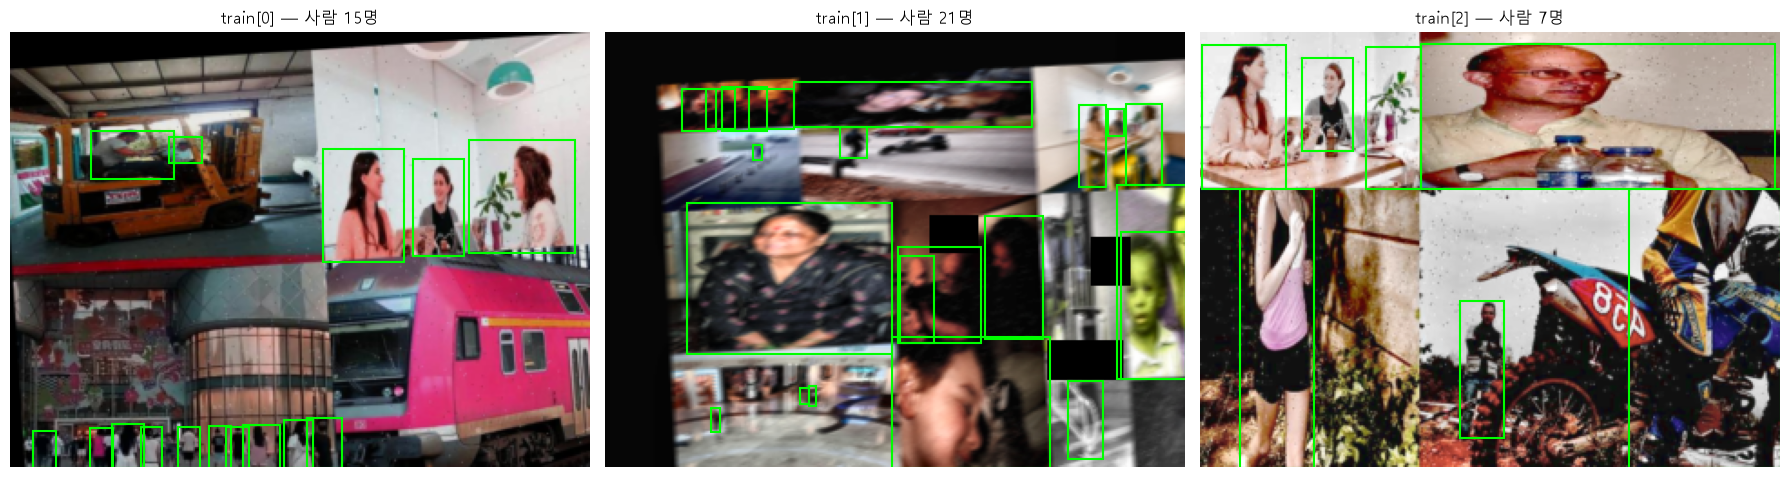

여러 번 다시 실행해보면(같은 인덱스라도) Mosaic 확률에 따라 매번 다른 조합이 나옵니다.


In [9]:
# ============================================================
# 샘플 시각화 — 일반 이미지 vs Mosaic 이미지 비교
#
# Mosaic가 적용되면 한 이미지 안의 사람 수/구도가 확 달라지는 걸
# 눈으로 확인할 수 있습니다. 학습을 시작하기 전에 박스 좌표가
# 제대로 그려지는지 반드시 확인하세요.
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    image, boxes = train_dataset[i]
    image_vis = image.permute(1, 2, 0).numpy()
    ax.imshow(image_vis)
    for box in boxes.numpy():
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                  linewidth=1.5, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(f"train[{i}] — 사람 {len(boxes)}명")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("여러 번 다시 실행해보면(같은 인덱스라도) Mosaic 확률에 따라 매번 다른 조합이 나옵니다.")

## 모델 구조 (v2)

```
입력 이미지 (3, H, W)
   │
   ▼
Stem (일반 Conv, stride 2)         ← 채널이 적을 때 미리 다운샘플 (저렴함)
   │
   ▼
Depthwise-Separable x2 (각 stride 2)  ← 8배 다운샘플까지 완료
   │
   ▼
Depthwise-Separable 여러 개 (stride 1, refine)  ← 해상도 유지, 채널만 확장(표현력 보강)
   │
   ▼
특징 맵 (C, H/8, W/8)
   │
   ▼
Head: Depthwise-Separable + 1x1 Conv
   │
   ▼
출력 (num_anchors, 5, H/8, W/8)
   채널 0   : objectness (이 anchor 위치에 사람이 있을 확률)
   채널 1~4 : (tx, ty, tw, th) — anchor 대비 위치/크기 보정값
```

**핵심 차이 (v1 대비)**: 격자 한 칸이 이제 **여러 개의 anchor**를 동시에 예측합니다. 한 칸에 사람이 여러 명 겹쳐도(밀집 상황), 크기/모양이 다른 anchor들이 각자 하나씩 담당할 수 있습니다. anchor 크기는 사람이 임의로 정하지 않고, 방금 계산한 k-means 결과를 그대로 사용합니다.

일반 Conv 대신 **Depthwise-Separable Conv**를 쓰는 이유: 일반 3x3 Conv 하나를 "공간 방향(depthwise) + 채널 방향(pointwise)" 두 단계로 쪼개면, 표현력은 거의 유지하면서 연산량은 몇 배 더 적게 듭니다. 라즈베리파이 같은 저사양 CPU에서 실시간 추론하려면 필수적인 선택입니다.

In [10]:
# ============================================================
# 모델 정의 — Depthwise-Separable Backbone + Multi-Anchor Head
# ============================================================
import torch.nn as nn


class ConvBNAct(nn.Module):
    """일반 conv + BN + ReLU6. (ReLU6은 출력이 0~6으로 제한되어, 나중에
    ONNX/양자화 변환 시 값 범위가 안정적이라 정확도 손실이 더 적습니다.)"""

    def __init__(self, cin, cout, k=3, stride=1, groups=1):
        super().__init__()
        padding = k // 2
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, k, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU6(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DepthwiseSeparable(nn.Module):
    """depthwise(칸마다 독립적으로 공간정보 처리) + pointwise(1x1로 채널 섞기).
    일반 conv를 이 두 단계로 쪼개면 표현력은 거의 유지하면서 연산량은
    몇 분의 1로 줄어듭니다 (MobileNet에서 널리 쓰이는 기법)."""

    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.depthwise = ConvBNAct(cin, cin, k=3, stride=stride, groups=cin)
        self.pointwise = ConvBNAct(cin, cout, k=1, stride=1)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class Backbone(nn.Module):
    """channels = (stem, 다운샘플1, 다운샘플2, refine...). 앞의 3단계에서
    8배 다운샘플을 마치고, 이후 refine 단계들은 해상도를 유지한 채
    채널만 넓혀가며 표현력을 보강합니다."""

    def __init__(self, channels=(32, 64, 128, 128, 256, 256, 256)):
        super().__init__()
        stem_c, dw1_c, dw2_c, *refine_c = channels

        self.stem = ConvBNAct(3, stem_c, k=3, stride=2)             # x2 다운샘플 (채널 작을때라 저렴)
        self.down1 = DepthwiseSeparable(stem_c, dw1_c, stride=2)     # x4 다운샘플
        self.down2 = DepthwiseSeparable(dw1_c, dw2_c, stride=2)      # x8 다운샘플 (이후 해상도 고정)

        refine_layers = []
        prev = dw2_c
        for c in refine_c:
            refine_layers.append(DepthwiseSeparable(prev, c, stride=1))
            prev = c
        self.refine = nn.Sequential(*refine_layers)
        self.out_channels = prev

    def forward(self, x):
        x = self.stem(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.refine(x)
        return x


class MultiAnchorHead(nn.Module):
    """격자 한 칸마다 num_anchors개의 (objectness + box 4개)를 동시에 예측"""

    def __init__(self, in_channels, num_anchors=5):
        super().__init__()
        self.num_anchors = num_anchors
        self.refine = DepthwiseSeparable(in_channels, in_channels, stride=1)
        self.predict = nn.Conv2d(in_channels, num_anchors * 5, kernel_size=1)

    def forward(self, x):
        x = self.refine(x)
        out = self.predict(x)                            # [B, A*5, H, W]
        b, _, h, w = out.shape
        out = out.view(b, self.num_anchors, 5, h, w)      # [B, A, 5, H, W]
        return out


class PersonDetectorV2(nn.Module):
    def __init__(self, backbone_channels=(32, 64, 128, 128, 256, 256, 256), num_anchors=5):
        super().__init__()
        self.backbone = Backbone(backbone_channels)
        self.head = MultiAnchorHead(self.backbone.out_channels, num_anchors=num_anchors)

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        # [B, A, 5, H, W] (raw logits, 채널0=objectness, 1~4=tx,ty,tw,th) — 아직 sigmoid/exp 적용 전
        return out


print("PersonDetectorV2 모델 클래스 정의 완료")

PersonDetectorV2 모델 클래스 정의 완료


In [11]:
# ============================================================
# 모델 생성 및 확인
# ============================================================
model = PersonDetectorV2(backbone_channels=BACKBONE_CHANNELS, num_anchors=NUM_ANCHORS).to(device)


def count_parameters(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable


total_params, trainable_params = count_parameters(model)
print(f"전체 파라미터 수     : {total_params:,}")
print(f"학습 가능 파라미터 수: {trainable_params:,}")

# 대략적인 연산량(MACs) 추정 — RPi4 배포 전 "이 정도면 빠를지" 감을 잡기 위함
def estimate_macs(channels, image_w, image_h, num_anchors):
    def dw_sep(cin, cout, h, w, stride=1):
        oh, ow = h // stride, w // stride
        return cin * 9 * oh * ow + cin * cout * oh * ow, oh, ow

    def std_conv(cin, cout, h, w, k, stride):
        oh, ow = h // stride, w // stride
        return cin * cout * k * k * oh * ow, oh, ow

    stem_c, dw1_c, dw2_c, *refine_c = channels
    total = 0
    m, h, w = std_conv(3, stem_c, image_h, image_w, 3, 2); total += m
    m, h, w = dw_sep(stem_c, dw1_c, h, w, 2); total += m
    m, h, w = dw_sep(dw1_c, dw2_c, h, w, 2); total += m
    prev = dw2_c
    for c in refine_c:
        m, h, w = dw_sep(prev, c, h, w, 1); total += m
        prev = c
    m, h, w = dw_sep(prev, prev, h, w, 1); total += m  # head의 refine
    m, h, w = std_conv(prev, num_anchors * 5, h, w, 1, 1); total += m  # head의 1x1
    return total

macs = estimate_macs(BACKBONE_CHANNELS, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_ANCHORS)
print(f"\n추정 연산량: {macs/1e6:.1f}M MACs ({macs*2/1e9:.3f} GFLOPs)")
print("  (참고: v1 finale 모델은 1837M MACs였습니다 — 훨씬 가벼워졌습니다)")

# 실제 forward pass로 출력 shape 확인
dummy_input = torch.randn(2, 3, IMAGE_HEIGHT, IMAGE_WIDTH).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"\n입력 shape : {tuple(dummy_input.shape)}")
print(f"출력 shape : {tuple(dummy_output.shape)}")

expected_shape = (2, NUM_ANCHORS, 5, GRID_H, GRID_W)
assert tuple(dummy_output.shape) == expected_shape, (
    f"모델 출력 shape이 예상과 다릅니다. 기대값={expected_shape}, 실제={tuple(dummy_output.shape)}"
)
print(f"✅ 출력 shape이 예상({expected_shape})과 일치합니다.")

전체 파라미터 수     : 278,361
학습 가능 파라미터 수: 278,361

추정 연산량: 352.0M MACs (0.704 GFLOPs)
  (참고: v1 finale 모델은 1837M MACs였습니다 — 훨씬 가벼워졌습니다)

입력 shape : (2, 3, 240, 320)
출력 shape : (2, 5, 5, 30, 40)
✅ 출력 shape이 예상((2, 5, 5, 30, 40))과 일치합니다.


In [12]:
# ============================================================
# Anchor 기반 Target 인코딩
#
# GT 박스를 (1) 어느 격자 칸에 속하는지, (2) 그 칸의 몇 번 anchor가
# 이 박스 모양과 가장 비슷한지 찾아서 배정합니다.
#
# 파라미터화 방식 (YOLOv2 스타일):
#   tx, ty : 칸 내부에서의 상대 위치 (0~1, sigmoid로 제한될 예정)
#   tw, th : anchor 대비 로그 스케일 비율 (양수/음수 제한 없음)
#     실제 좌표 복원 시: cx=(gx+sigmoid(tx))*cell_w, w=anchor_w*exp(tw)
#
# ignore_mask: best는 아니지만 GT와 어느 정도(IGNORE_IOU_THRESH 이상)
# 비슷한 모양의 다른 anchor는 "음성으로 벌주지 않음" 처리합니다.
# (충분히 비슷한 예측까지 억지로 background로 학습시키면 오히려 불안정해짐)
# ============================================================
def box_iou_wh_torch(wh1, wh2):
    w1, h1 = wh1[:, 0:1], wh1[:, 1:2]
    w2, h2 = wh2[:, 0], wh2[:, 1]
    inter = torch.minimum(w1, w2) * torch.minimum(h1, h2)
    area1 = w1 * h1
    area2 = (w2 * h2)[None, :]
    union = area1 + area2 - inter
    return inter / union.clamp(min=1e-9)


def encode_targets(boxes_xyxy, anchors_wh, grid_h, grid_w, image_w, image_h,
                    ignore_iou_thresh=0.5):
    boxes_xyxy = boxes_xyxy.to(anchors_wh.device)
    A = anchors_wh.shape[0]
    target = torch.zeros(A, 5, grid_h, grid_w)
    pos_mask = torch.zeros(A, grid_h, grid_w, dtype=torch.bool)
    ignore_mask = torch.zeros(A, grid_h, grid_w, dtype=torch.bool)

    cell_w, cell_h = image_w / grid_w, image_h / grid_h
    if boxes_xyxy.numel() == 0:
        return target, pos_mask, ignore_mask

    cx = (boxes_xyxy[:, 0] + boxes_xyxy[:, 2]) / 2
    cy = (boxes_xyxy[:, 1] + boxes_xyxy[:, 3]) / 2
    gw = (boxes_xyxy[:, 2] - boxes_xyxy[:, 0]).clamp(min=1e-3)
    gh = (boxes_xyxy[:, 3] - boxes_xyxy[:, 1]).clamp(min=1e-3)

    gx = (cx / cell_w).long().clamp(0, grid_w - 1)
    gy = (cy / cell_h).long().clamp(0, grid_h - 1)

    ious = box_iou_wh_torch(torch.stack([gw, gh], dim=1), anchors_wh)   # [N, A]
    best_anchor = ious.argmax(dim=1)

    for i in range(boxes_xyxy.shape[0]):
        a, y, x = int(best_anchor[i]), int(gy[i]), int(gx[i])

        pos_mask[a, y, x] = True
        target[a, 0, y, x] = 1.0
        target[a, 1, y, x] = (cx[i] / cell_w) - x
        target[a, 2, y, x] = (cy[i] / cell_h) - y
        target[a, 3, y, x] = torch.log(gw[i] / anchors_wh[a, 0])
        target[a, 4, y, x] = torch.log(gh[i] / anchors_wh[a, 1])

        high_iou = (ious[i] > ignore_iou_thresh).nonzero(as_tuple=True)[0]
        for a2 in high_iou.tolist():
            if a2 != a:
                ignore_mask[a2, y, x] = True

    return target, pos_mask, ignore_mask


def make_batch_targets(boxes_list, anchors_wh, grid_h, grid_w, image_w, image_h, ignore_iou_thresh):
    targets, pos_masks, ignore_masks = [], [], []
    for boxes in boxes_list:
        t, p, ig = encode_targets(boxes, anchors_wh, grid_h, grid_w, image_w, image_h, ignore_iou_thresh)
        targets.append(t); pos_masks.append(p); ignore_masks.append(ig)
    return torch.stack(targets), torch.stack(pos_masks), torch.stack(ignore_masks)


# 배치 하나로 shape 확인
_img_batch, _boxes_list = next(iter(train_loader))
_t, _p, _ig = make_batch_targets(_boxes_list, ANCHORS_WH, GRID_H, GRID_W, IMAGE_WIDTH, IMAGE_HEIGHT, IGNORE_IOU_THRESH)
print("Images shape :", _img_batch.shape)
print("Targets shape:", _t.shape, " (기대: [B, A, 5, H, W])")
print(f"이 배치의 양성(positive) anchor-cell 수: {int(_p.sum().item())}")

Images shape : torch.Size([32, 3, 240, 320])
Targets shape: torch.Size([32, 5, 5, 30, 40])  (기대: [B, A, 5, H, W])
이 배치의 양성(positive) anchor-cell 수: 375


In [13]:
# ============================================================
# Loss 함수 — Focal Loss(objectness) + CIoU Loss(box regression)
#
# [objectness: Focal Loss]
# RetinaNet 논문에서 제안된 손실함수로, "이미 잘 맞춘 쉬운 칸"의 loss를
# 깎아서 "아직 헷갈려하는 어려운 칸"에 학습이 더 집중되게 합니다.
#
# ⚠️ 중요(실제로 겪은 버그): 양성 칸이 전체의 0.1% 미만일 정도로 극히
# 드물기 때문에, loss를 "전체 칸 개수"로 나누면(mean) 압도적으로 많은
# 음성 칸이 평균을 지배해서 정작 양성 칸에는 학습 신호가 거의 전달되지
# 않습니다. 그래서 RetinaNet 논문처럼 "양성 칸 개수"로 정규화합니다.
#
# [box: CIoU Loss]
# 4개 좌표(cx,cy,w,h)를 각각 따로 맞추는 대신, 예측 박스와 정답 박스의
# 실제 겹침 정도(IoU) + 중심점 거리 + 종횡비 차이를 한 번에 고려하는
# 손실함수입니다. 우리가 최종적으로 원하는 지표(IoU)에 훨씬 가깝게
# 직접 최적화합니다.
# ============================================================
import math
import torch.nn.functional as F


def focal_loss(pred_logits, target, alpha=0.25, gamma=2.0):
    prob = torch.sigmoid(pred_logits)
    ce = F.binary_cross_entropy_with_logits(pred_logits, target, reduction="none")
    p_t = prob * target + (1 - prob) * (1 - target)
    loss = ce * ((1 - p_t) ** gamma)
    alpha_t = alpha * target + (1 - alpha) * (1 - target)
    return (alpha_t * loss).sum()


def bbox_ciou(pred_xyxy, target_xyxy, eps=1e-7):
    px1, py1, px2, py2 = pred_xyxy.unbind(-1)
    tx1, ty1, tx2, ty2 = target_xyxy.unbind(-1)

    inter_x1 = torch.maximum(px1, tx1); inter_y1 = torch.maximum(py1, ty1)
    inter_x2 = torch.minimum(px2, tx2); inter_y2 = torch.minimum(py2, ty2)
    inter = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    area_p = (px2 - px1).clamp(min=0) * (py2 - py1).clamp(min=0)
    area_t = (tx2 - tx1).clamp(min=0) * (ty2 - ty1).clamp(min=0)
    union = area_p + area_t - inter + eps
    iou = inter / union

    p_cx, p_cy = (px1 + px2) / 2, (py1 + py2) / 2
    t_cx, t_cy = (tx1 + tx2) / 2, (ty1 + ty2) / 2
    center_dist_sq = (p_cx - t_cx) ** 2 + (p_cy - t_cy) ** 2

    enclose_x1 = torch.minimum(px1, tx1); enclose_y1 = torch.minimum(py1, ty1)
    enclose_x2 = torch.maximum(px2, tx2); enclose_y2 = torch.maximum(py2, ty2)
    enclose_diag_sq = (enclose_x2 - enclose_x1) ** 2 + (enclose_y2 - enclose_y1) ** 2 + eps

    p_w, p_h = (px2 - px1).clamp(min=eps), (py2 - py1).clamp(min=eps)
    t_w, t_h = (tx2 - tx1).clamp(min=eps), (ty2 - ty1).clamp(min=eps)
    v = (4 / (math.pi ** 2)) * (torch.atan(t_w / t_h) - torch.atan(p_w / p_h)) ** 2
    with torch.no_grad():
        alpha = v / (1 - iou + v + eps)

    return iou - (center_dist_sq / enclose_diag_sq) - alpha * v


class DetectionLossV2(nn.Module):
    def __init__(self, anchors_wh, image_w, image_h, box_weight=2.0,
                 focal_alpha=0.25, focal_gamma=2.0):
        super().__init__()
        self.register_buffer("anchors_wh", anchors_wh.clone().detach())
        self.image_w = image_w
        self.image_h = image_h
        self.box_weight = box_weight
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma

    def _grid_xy(self, h, w, device):
        gy, gx = torch.meshgrid(torch.arange(h, device=device), torch.arange(w, device=device), indexing="ij")
        return gx.view(1, 1, h, w).float(), gy.view(1, 1, h, w).float()

    def _decode_pred(self, raw_txywh, grid_h, grid_w):
        b, a, _, h, w = raw_txywh.shape
        gx, gy = self._grid_xy(h, w, raw_txywh.device)
        cell_w, cell_h = self.image_w / grid_w, self.image_h / grid_h

        tx = torch.sigmoid(raw_txywh[:, :, 0]); ty = torch.sigmoid(raw_txywh[:, :, 1])
        tw = raw_txywh[:, :, 2].clamp(max=6.0); th = raw_txywh[:, :, 3].clamp(max=6.0)

        cx = (gx + tx) * cell_w; cy = (gy + ty) * cell_h
        aw = self.anchors_wh[:, 0].view(1, a, 1, 1); ah = self.anchors_wh[:, 1].view(1, a, 1, 1)
        bw = aw * torch.exp(tw); bh = ah * torch.exp(th)

        return torch.stack([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2], dim=2)

    def _decode_target(self, target_txywh, grid_h, grid_w):
        b, a, _, h, w = target_txywh.shape
        gx, gy = self._grid_xy(h, w, target_txywh.device)
        cell_w, cell_h = self.image_w / grid_w, self.image_h / grid_h

        tx, ty = target_txywh[:, :, 0], target_txywh[:, :, 1]
        tw, th = target_txywh[:, :, 2], target_txywh[:, :, 3]

        cx = (gx + tx) * cell_w; cy = (gy + ty) * cell_h
        aw = self.anchors_wh[:, 0].view(1, a, 1, 1); ah = self.anchors_wh[:, 1].view(1, a, 1, 1)
        bw = aw * torch.exp(tw); bh = ah * torch.exp(th)

        return torch.stack([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2], dim=2)

    def forward(self, predictions, targets, pos_mask, ignore_mask):
        obj_pred = predictions[:, :, 0]
        obj_target = targets[:, :, 0]

        valid = ~ignore_mask
        num_pos_raw = pos_mask.sum()
        num_pos = num_pos_raw.clamp(min=1)

        obj_loss = focal_loss(obj_pred[valid], obj_target[valid],
                               alpha=self.focal_alpha, gamma=self.focal_gamma) / num_pos

        if num_pos_raw > 0:
            b, a, _, h, w = predictions.shape
            pred_xyxy = self._decode_pred(predictions[:, :, 1:5], h, w)
            target_xyxy = self._decode_target(targets[:, :, 1:5], h, w)

            pred_pos = pred_xyxy.permute(0, 1, 3, 4, 2)[pos_mask]
            target_pos = target_xyxy.permute(0, 1, 3, 4, 2)[pos_mask]

            ciou = bbox_ciou(pred_pos, target_pos)
            box_loss = (1 - ciou).mean()
        else:
            box_loss = torch.tensor(0.0, device=predictions.device)

        total = obj_loss + self.box_weight * box_loss
        return total, obj_loss.detach(), box_loss.detach()


print("DetectionLossV2 (Focal + CIoU) 정의 완료")

DetectionLossV2 (Focal + CIoU) 정의 완료


In [14]:
# ============================================================
# 평가지표 — v1과 달리 "배치별 평균"이 아니라 "검증셋 전체를 다 합산한
# 뒤 딱 한 번 계산"하는 micro-average 방식입니다. (지난번 발견한 문제 수정)
#
# 그리고 사용자가 지정한 목표(TARGET_MIN_PRECISION/RECALL/GOAL)를
# 만족하는지 매번 자동으로 함께 계산합니다.
# ============================================================
class EpochMetricAccumulator:
    def __init__(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.iou_sum = 0.0
        self.iou_count = 0

    def update(self, pred_object, gt_object, iou_map=None):
        tp_mask = pred_object & gt_object
        self.tp += tp_mask.sum().item()
        self.fp += (pred_object & (~gt_object)).sum().item()
        self.fn += ((~pred_object) & gt_object).sum().item()
        if iou_map is not None and tp_mask.any():
            self.iou_sum += iou_map[tp_mask].sum().item()
            self.iou_count += tp_mask.sum().item()

    def compute(self, target_precision=0.6, target_recall=0.6, goal=0.85, eps=1e-6):
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        mean_iou = self.iou_sum / self.iou_count if self.iou_count > 0 else 0.0
        return {
            "precision": precision, "recall": recall, "f1": f1, "iou": mean_iou,
            "tp": self.tp, "fp": self.fp, "fn": self.fn,
            "meets_min_precision": precision >= target_precision,
            "meets_min_recall": recall >= target_recall,
            "meets_both_min": (precision >= target_precision) and (recall >= target_recall),
            "meets_goal": (precision >= goal) and (recall >= goal),
        }


def batch_pred_gt_iou(predictions, targets, pos_mask, anchors_wh, image_w, image_h, threshold):
    """한 배치에 대해 (pred_object, gt_object, iou_map) 텐서를 계산합니다."""
    obj_prob = torch.sigmoid(predictions[:, :, 0])
    pred_object = obj_prob > threshold
    gt_object = targets[:, :, 0] > 0.5

    tp_candidate = pred_object & gt_object
    iou_map = torch.zeros_like(obj_prob)

    if tp_candidate.any():
        b, a, _, h, w = predictions.shape
        gy, gx = torch.meshgrid(torch.arange(h, device=predictions.device),
                                 torch.arange(w, device=predictions.device), indexing="ij")
        gx = gx.view(1, 1, h, w).float(); gy = gy.view(1, 1, h, w).float()
        cell_w, cell_h = image_w / w, image_h / h

        def decode(txywh, is_pred):
            tx = torch.sigmoid(txywh[:, :, 0]) if is_pred else txywh[:, :, 0]
            ty = torch.sigmoid(txywh[:, :, 1]) if is_pred else txywh[:, :, 1]
            tw = txywh[:, :, 2].clamp(max=6.0)
            th = txywh[:, :, 3].clamp(max=6.0)
            cx = (gx + tx) * cell_w; cy = (gy + ty) * cell_h
            aw = anchors_wh[:, 0].view(1, a, 1, 1); ah = anchors_wh[:, 1].view(1, a, 1, 1)
            bw = aw * torch.exp(tw); bh = ah * torch.exp(th)
            return torch.stack([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2], dim=2)

        pred_xyxy = decode(predictions[:, :, 1:5], is_pred=True)
        target_xyxy = decode(targets[:, :, 1:5], is_pred=False)

        px1, py1, px2, py2 = pred_xyxy.unbind(2)
        tx1, ty1, tx2, ty2 = target_xyxy.unbind(2)
        ix1 = torch.maximum(px1, tx1); iy1 = torch.maximum(py1, ty1)
        ix2 = torch.minimum(px2, tx2); iy2 = torch.minimum(py2, ty2)
        inter = (ix2 - ix1).clamp(min=0) * (iy2 - iy1).clamp(min=0)
        area_p = (px2-px1).clamp(min=0)*(py2-py1).clamp(min=0)
        area_t = (tx2-tx1).clamp(min=0)*(ty2-ty1).clamp(min=0)
        union = (area_p + area_t - inter).clamp(min=1e-9)
        iou_map = inter / union

    return pred_object, gt_object, iou_map


print("EpochMetricAccumulator, batch_pred_gt_iou 정의 완료")

EpochMetricAccumulator, batch_pred_gt_iou 정의 완료


In [15]:
# ============================================================
# Criterion / Optimizer / Scheduler / AMP Scaler
# ============================================================
ANCHORS_WH = ANCHORS_WH.to(device)

criterion = DetectionLossV2(
    ANCHORS_WH, IMAGE_WIDTH, IMAGE_HEIGHT,
    box_weight=BOX_LOSS_WEIGHT, focal_alpha=FOCAL_ALPHA, focal_gamma=FOCAL_GAMMA,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE,
)

amp_enabled = USE_AMP and device.type == "cuda"
scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)

print("Criterion :", type(criterion).__name__)
print("Optimizer :", optimizer)
print(f"Scheduler : ReduceLROnPlateau (factor={SCHEDULER_FACTOR}, patience={SCHEDULER_PATIENCE})")
print("AMP 활성화 :", scaler.is_enabled())

Criterion : DetectionLossV2
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)
AMP 활성화 : True


In [16]:
# ============================================================
# evaluate() — 검증/테스트 데이터셋 전체에 대해 loss와 지표를 계산
# find_best_threshold() — 여러 threshold를 시도해 F1이 가장 높은 값을 탐색
# ============================================================
@torch.no_grad()
def evaluate(model, loader, criterion, anchors_wh, threshold=0.4, use_amp=True):
    model.eval()
    amp_enabled = use_amp and device.type == "cuda"

    total_loss = 0.0
    num_batches = 0
    accumulator = EpochMetricAccumulator()

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)
    for images, boxes_list in progress_bar:
        images = images.to(device, non_blocking=True)
        targets, pos_mask, ignore_mask = make_batch_targets(
            boxes_list, anchors_wh, GRID_H, GRID_W, IMAGE_WIDTH, IMAGE_HEIGHT, IGNORE_IOU_THRESH
        )
        targets = targets.to(device); pos_mask = pos_mask.to(device); ignore_mask = ignore_mask.to(device)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            outputs = model(images)
            loss, obj_l, box_l = criterion(outputs, targets, pos_mask, ignore_mask)

        total_loss += loss.item()
        num_batches += 1

        pred_object, gt_object, iou_map = batch_pred_gt_iou(
            outputs.float(), targets, pos_mask, anchors_wh, IMAGE_WIDTH, IMAGE_HEIGHT, threshold
        )
        accumulator.update(pred_object, gt_object, iou_map)

        progress_bar.set_postfix(loss=loss.item())

    metrics = accumulator.compute(TARGET_MIN_PRECISION, TARGET_MIN_RECALL, TARGET_GOAL)
    metrics["loss"] = total_loss / max(num_batches, 1)
    return metrics


@torch.no_grad()
def find_best_threshold(model, loader, criterion, anchors_wh, thresholds=None, use_amp=True):
    if thresholds is None:
        thresholds = np.arange(0.20, 0.81, 0.05)

    records = []
    for th in thresholds:
        m = evaluate(model, loader, criterion, anchors_wh, threshold=float(th), use_amp=use_amp)
        m["threshold"] = float(th)
        records.append(m)

    df = pd.DataFrame(records)
    best_idx = df["f1"].idxmax()
    return df.loc[best_idx].to_dict(), df


print("evaluate(), find_best_threshold() 정의 완료")

evaluate(), find_best_threshold() 정의 완료


In [17]:
# ============================================================
# 체크포인트 저장 / 불러오기
#
# v1과 달리 anchor 정보도 함께 저장합니다. anchor는 데이터셋에서 계산된
# 값이라, 나중에 데이터셋을 바꾸고 이어받으면 이전 anchor와 안 맞을 수
# 있기 때문에 resume 시 이 값을 비교해서 안전하게 처리합니다.
# ============================================================
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler,
                     best_f1, best_threshold, early_stop_counter):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "best_f1": best_f1,
        "best_threshold": best_threshold,
        "early_stop_counter": early_stop_counter,
        "image_width": IMAGE_WIDTH,
        "image_height": IMAGE_HEIGHT,
        "grid_w": GRID_W,
        "grid_h": GRID_H,
        "num_anchors": NUM_ANCHORS,
        "anchors_wh": ANCHORS_WH.detach().cpu().tolist(),
        "backbone_channels": list(BACKBONE_CHANNELS),
        "threshold": best_threshold,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    scaler_state = checkpoint.get("scaler_state_dict")
    if scaler is not None and scaler_state:
        scaler.load_state_dict(scaler_state)
    return checkpoint


print("save_checkpoint / load_checkpoint 정의 완료")

save_checkpoint / load_checkpoint 정의 완료


In [18]:
# ============================================================
# 추론(inference) 관련 함수 — anchor 기반 디코딩 + NMS
# ============================================================
def compute_iou_xyxy(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a[:4]
    xb1, yb1, xb2, yb2 = box_b[:4]
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def non_max_suppression(boxes, iou_threshold=0.5):
    if len(boxes) == 0:
        return []
    boxes_sorted = sorted(boxes, key=lambda b: b[4], reverse=True)
    keep = []
    while boxes_sorted:
        best = boxes_sorted.pop(0)
        keep.append(best)
        boxes_sorted = [b for b in boxes_sorted if compute_iou_xyxy(best, b) < iou_threshold]
    return keep


def decode_predictions_v2(output, anchors_wh, image_w, image_h, threshold=0.4):
    """output: [A, 5, H, W] (배치 1개 이미지분, raw logits)"""
    A, _, H, W = output.shape
    cell_w, cell_h = image_w / W, image_h / H

    obj = torch.sigmoid(output[:, 0])            # [A,H,W]
    tx = torch.sigmoid(output[:, 1]); ty = torch.sigmoid(output[:, 2])
    tw = output[:, 3].clamp(max=6.0); th = output[:, 4].clamp(max=6.0)

    device_ = output.device
    gy, gx = torch.meshgrid(torch.arange(H, device=device_), torch.arange(W, device=device_), indexing="ij")
    gx = gx.unsqueeze(0).expand(A, -1, -1).float()
    gy = gy.unsqueeze(0).expand(A, -1, -1).float()

    cx = (gx + tx) * cell_w; cy = (gy + ty) * cell_h
    aw = anchors_wh[:, 0].view(A, 1, 1); ah = anchors_wh[:, 1].view(A, 1, 1)
    bw = aw * torch.exp(tw); bh = ah * torch.exp(th)

    xmin = cx - bw / 2; ymin = cy - bh / 2
    xmax = cx + bw / 2; ymax = cy + bh / 2

    mask = obj > threshold
    results = []
    for a, y, x in mask.nonzero(as_tuple=False).tolist():
        results.append([
            xmin[a, y, x].item(), ymin[a, y, x].item(),
            xmax[a, y, x].item(), ymax[a, y, x].item(),
            obj[a, y, x].item(),
        ])
    return results


def draw_boxes(ax, boxes, color="red", label_prefix="GT"):
    for i, box in enumerate(boxes):
        xmin, ymin, xmax, ymax = box[:4]
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                  linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        label = f"{label_prefix} {i + 1}"
        if len(box) >= 5:
            label += f": {box[4]:.2f}"
        ax.text(xmin, max(0, ymin - 5), label, color=color, fontsize=9,
                 bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))


def save_prediction_snapshot(model, dataset, indices, epoch, save_dir, threshold, nms_iou, anchors_wh):
    if len(indices) == 0:
        return None
    model.eval()
    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image, gt_boxes = dataset[idx]
            pred = model(image.unsqueeze(0).to(device))[0]
            pred_boxes = decode_predictions_v2(pred, anchors_wh, IMAGE_WIDTH, IMAGE_HEIGHT, threshold)
            pred_boxes = non_max_suppression(pred_boxes, nms_iou)

            img_np = image.permute(1, 2, 0).numpy()
            ax.imshow(img_np)
            draw_boxes(ax, gt_boxes.numpy(), color="lime", label_prefix="GT")
            draw_boxes(ax, pred_boxes, color="red", label_prefix="Pred")
            ax.set_title(f"epoch {epoch} | val[{idx}] GT={len(gt_boxes)} Pred={len(pred_boxes)}")
            ax.axis("off")

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"epoch_{epoch:03d}.png")
    plt.savefig(save_path, dpi=100)
    plt.close(fig)
    model.train()
    return save_path


SNAPSHOT_SAMPLE_INDICES = list(range(min(3, len(val_dataset))))
print(f"스냅샷 추적 대상 검증 이미지 index: {SNAPSHOT_SAMPLE_INDICES}")

스냅샷 추적 대상 검증 이미지 index: [0, 1, 2]


## 학습 루프에서 매 epoch마다 일어나는 일

1. **train_one_epoch**: train 데이터(Mosaic로 매번 다르게 합성됨)로 가중치 업데이트 → `Train Loss`
2. **evaluate**: valid 데이터로 성능 측정(micro-average) → `Valid Loss`, `Precision`, `Recall`, `F1`, `Box IoU`
3. **목표 달성 체크**: Precision·Recall이 각각 `TARGET_MIN_PRECISION`(0.6) 이상인지, `TARGET_GOAL`(0.85) 이상인지 자동으로 표시
4. **scheduler.step(f1)**: F1이 정체되면 학습률 감소 → `📉 Learning Rate 감소`로 표시
5. **best 판단**: F1이 지금까지 중 최고면 → best 체크포인트 저장, `🌟 Best 모델 갱신!`
6. **스냅샷**: `SNAPSHOT_EVERY` epoch마다 예측 결과 이미지 저장
7. (`USE_EARLY_STOPPING=True`인 경우만) `PATIENCE` epoch 연속 미개선 시 조기 종료. 기본은 False라 지정한 epoch을 끝까지 진행합니다.

**"이 모델이 최소 기준(0.6)을 넘었는가?"**는 매 epoch `[목표 달성: Precision ✅/❌  Recall ✅/❌]` 형태로 명확히 표시됩니다. 0.85(목표)를 넘으면 `🎯 목표 달성!`이 추가로 표시됩니다.

In [19]:
# ============================================================
# 학습 재개(Resume) 로직
# ============================================================
history = []
start_epoch = 0
best_f1 = -1.0   # -1로 시작해야 F1=0.0000인 첫 epoch도 반드시 best로 저장됨
best_threshold = CONF_THRESHOLD
early_stop_counter = 0

if RESUME and os.path.exists(LOG_CSV_PATH):
    try:
        history = pd.read_csv(LOG_CSV_PATH).to_dict("records")
    except Exception as e:
        print(f"이전 로그 CSV를 읽는 중 문제 발생, 로그는 새로 시작합니다: {e}")
        history = []

if RESUME and os.path.exists(LAST_MODEL_PATH):
    probe = torch.load(LAST_MODEL_PATH, map_location="cpu", weights_only=True)

    grid_mismatch = (probe.get("grid_w") != GRID_W) or (probe.get("grid_h") != GRID_H)
    anchor_mismatch = probe.get("num_anchors") != NUM_ANCHORS

    if grid_mismatch or anchor_mismatch:
        print("⚠️ 저장된 체크포인트가 현재 설정(격자 크기 또는 anchor 개수)과 다릅니다.")
        print(f"   체크포인트: grid={probe.get('grid_w')}x{probe.get('grid_h')}, anchors={probe.get('num_anchors')}")
        print(f"   현재 설정 : grid={GRID_W}x{GRID_H}, anchors={NUM_ANCHORS}")
        print("   (IMAGE_WIDTH/HEIGHT, NUM_ANCHORS, BACKBONE_CHANNELS 등을 바꾼 뒤")
        print("    같은 EXPERIMENT_NAME으로 이어받으려 할 때 발생합니다)")
        print("   호환되지 않으므로 이어받기를 건너뛰고 처음부터 학습을 시작합니다.")
        history = []
    else:
        print("=" * 70)
        print("이전 학습을 이어서 진행합니다 (Resume)")
        print("=" * 70)
        checkpoint = load_checkpoint(LAST_MODEL_PATH, model, optimizer=optimizer, scheduler=scheduler, scaler=scaler)
        start_epoch = int(checkpoint.get("epoch", 0))
        best_f1 = float(checkpoint.get("best_f1", -1.0))
        best_threshold = float(checkpoint.get("best_threshold", CONF_THRESHOLD))
        early_stop_counter = int(checkpoint.get("early_stop_counter", 0))

        print(f"이어받는 시작 Epoch : {start_epoch + 1}")
        print(f"지금까지 Best F1    : {best_f1:.4f}")
        print(f"Best Threshold      : {best_threshold:.2f}")
        print(f"EarlyStop 카운터    : {early_stop_counter}/{PATIENCE}")

        if start_epoch >= NUM_EPOCHS:
            print(f"\n⚠️ 이미 저장된 체크포인트가 NUM_EPOCHS({NUM_EPOCHS})에 도달했습니다.")
            print("   더 학습하려면 NUM_EPOCHS를 늘리거나 EXPERIMENT_NAME을 바꿔 새로 시작하세요.")
else:
    print("이어받을 체크포인트가 없어 처음부터 학습을 시작합니다.")

prev_lr = optimizer.param_groups[0]["lr"]

이전 학습을 이어서 진행합니다 (Resume)
이어받는 시작 Epoch : 2
지금까지 Best F1    : -1.0000
Best Threshold      : 0.40
EarlyStop 카운터    : 0/15


In [20]:
# ============================================================
# 한 epoch 학습 함수
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, scaler, anchors_wh, grad_clip_norm, use_amp):
    model.train()
    amp_enabled = use_amp and device.type == "cuda"

    total_loss = 0.0
    total_obj_loss = 0.0
    total_box_loss = 0.0
    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, boxes_list in progress_bar:
        images = images.to(device, non_blocking=True)
        targets, pos_mask, ignore_mask = make_batch_targets(
            boxes_list, anchors_wh, GRID_H, GRID_W, IMAGE_WIDTH, IMAGE_HEIGHT, IGNORE_IOU_THRESH
        )
        targets = targets.to(device); pos_mask = pos_mask.to(device); ignore_mask = ignore_mask.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            predictions = model(images)
            loss, obj_l, box_l = criterion(predictions, targets, pos_mask, ignore_mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_obj_loss += obj_l.item()
        total_box_loss += box_l.item()
        progress_bar.set_postfix(loss=loss.item(), obj=obj_l.item(), box=box_l.item())

    n = max(len(loader), 1)
    return total_loss / n, total_obj_loss / n, total_box_loss / n


print("train_one_epoch 함수 정의 완료")

train_one_epoch 함수 정의 완료


In [ ]:
# ============================================================
# 메인 학습 루프
# ============================================================
print("\n" + "=" * 70)
print(f"학습 시작: Epoch {start_epoch + 1} ~ {NUM_EPOCHS}")
print(f"목표: Precision·Recall 각 최소 {TARGET_MIN_PRECISION}, 목표 {TARGET_GOAL}")
print(f"Early Stopping: {USE_EARLY_STOPPING} (Patience={PATIENCE})")
print("=" * 70 + "\n")

epoch_times = []

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    train_loss, train_obj_loss, train_box_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, ANCHORS_WH.to(device), GRAD_CLIP_NORM, USE_AMP,
    )
    val_metrics = evaluate(model, valid_loader, criterion, ANCHORS_WH.to(device), threshold=CONF_THRESHOLD, use_amp=USE_AMP)
    f1 = val_metrics["f1"]
    scheduler.step(f1)
    current_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss, "train_obj_loss": train_obj_loss, "train_box_loss": train_box_loss,
        "valid_loss": val_metrics["loss"],
        "precision": val_metrics["precision"], "recall": val_metrics["recall"],
        "f1": f1, "iou": val_metrics["iou"],
        "lr": current_lr, "threshold": CONF_THRESHOLD, "epoch_time_sec": epoch_time,
    })
    pd.DataFrame(history).to_csv(LOG_CSV_PATH, index=False)

    print("=" * 70)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]  ({epoch_time:.1f}초, 평균 {np.mean(epoch_times):.1f}초/epoch)")
    print(f"  Train Loss : {train_loss:.4f}  (obj={train_obj_loss:.4f}, box={train_box_loss:.4f})")
    print(f"  Valid Loss : {val_metrics['loss']:.4f}")
    print(f"  Precision  : {val_metrics['precision']:.4f}  {'✅' if val_metrics['meets_min_precision'] else '❌'} (목표 {TARGET_MIN_PRECISION})")
    print(f"  Recall     : {val_metrics['recall']:.4f}  {'✅' if val_metrics['meets_min_recall'] else '❌'} (목표 {TARGET_MIN_RECALL})")
    print(f"  F1         : {f1:.4f}")
    print(f"  Box IoU    : {val_metrics['iou']:.4f}")
    print(f"  LR         : {current_lr:.6f}")
    if val_metrics["meets_goal"]:
        print(f"  🎯 목표(각 {TARGET_GOAL}) 달성!")

    if current_lr < prev_lr:
        print(f"  📉 Learning Rate 감소: {prev_lr:.6f} → {current_lr:.6f} "
              f"(F1이 최근 {SCHEDULER_PATIENCE}epoch 동안 개선되지 않음)")
    prev_lr = current_lr

    save_checkpoint(LAST_MODEL_PATH, epoch + 1, model, optimizer, scheduler, scaler,
                     best_f1, best_threshold, early_stop_counter)

    if f1 > best_f1:
        if best_f1 < 0:
            print(f"  🌟 첫 Best 모델 저장! Valid F1 = {f1:.4f}")
        else:
            print(f"  🌟 Best 모델 갱신! Valid F1 {best_f1:.4f} → {f1:.4f} (+{f1 - best_f1:.4f})")
        best_f1 = f1
        best_threshold = CONF_THRESHOLD
        early_stop_counter = 0
        save_checkpoint(BEST_MODEL_PATH, epoch + 1, model, optimizer, scheduler, scaler,
                         best_f1, best_threshold, early_stop_counter)
    else:
        early_stop_counter += 1
        print(f"  Best 기록(F1={best_f1:.4f}) 갱신 실패 (연속 {early_stop_counter}회)")
        if USE_EARLY_STOPPING:
            print(f"  EarlyStopping 카운터: {early_stop_counter}/{PATIENCE}")

    if (epoch + 1) % SNAPSHOT_EVERY == 0 or (epoch + 1) == NUM_EPOCHS:
        snap_path = save_prediction_snapshot(
            model, val_dataset, SNAPSHOT_SAMPLE_INDICES, epoch + 1, PREDICT_DIR,
            CONF_THRESHOLD, NMS_IOU_THRESHOLD, ANCHORS_WH,
        )
        if snap_path:
            print(f"  🖼  예측 스냅샷 저장: {snap_path}")

    print("=" * 70)

    if USE_EARLY_STOPPING and early_stop_counter >= PATIENCE:
        print(f"\nEarly Stopping 발동: F1이 {PATIENCE}epoch 연속 개선되지 않아 학습을 종료합니다.")
        break

print("\n학습 루프 종료.")
print(f"진행된 epoch 수 : {len(history)}")
print(f"최고 Valid F1   : {best_f1:.4f}")


학습 시작: Epoch 2 ~ 100
목표: Precision·Recall 각 최소 0.6, 목표 0.85
Early Stopping: True (Patience=15)



Training:   0%|          | 0/414 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [2/100]  (1585.2초, 평균 1585.2초/epoch)
  Train Loss : 1.5145  (obj=0.5751, box=0.4697)
  Valid Loss : 1.7517
  Precision  : 0.0000  ❌ (목표 0.6)
  Recall     : 0.0000  ❌ (목표 0.6)
  F1         : 0.0000
  Box IoU    : 0.0000
  LR         : 0.001000
  🌟 첫 Best 모델 저장! Valid F1 = 0.0000


Training:   0%|          | 0/414 [00:00<?, ?it/s]

...

Epoch [41/100]  (1556.1초, 평균 1555.3초/epoch)
  Train Loss : 1.1380  (obj=0.3964, box=0.3708)
  Valid Loss : 1.2955
  Precision  : 0.5986  ❌ (목표 0.6)
  Recall     : 0.1508  ❌ (목표 0.6)
  F1         : 0.2410
  Box IoU    : 0.6654
  LR         : 0.000250
  Best 기록(F1=0.2622) 갱신 실패 (연속 1회)
  EarlyStopping 카운터: 1/15


Training:   0%|          | 0/414 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [42/100]  (1582.6초, 평균 1556.0초/epoch)
  Train Loss : 1.1365  (obj=0.3961, box=0.3702)
  Valid Loss : 1.2680
  Precision  : 0.5864  ❌ (목표 0.6)
  Recall     : 0.1652  ❌ (목표 0.6)
  F1         : 0.2577
  Box IoU    : 0.6678
  LR         : 0.000250
  Best 기록(F1=0.2622) 갱신 실패 (연속 2회)
  EarlyStopping 카운터: 2/15


Training:   0%|          | 0/414 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 학습 곡선 시각화 — 0.6/0.85 목표선을 같이 그려서 얼마나 가까워졌는지 한눈에 확인
# ============================================================
history_df = pd.DataFrame(history)
print(history_df.tail())

if len(history_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(19, 10))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
    axes[0, 0].plot(history_df["epoch"], history_df["valid_loss"], label="Validation")
    axes[0, 0].set_title("Loss"); axes[0, 0].set_xlabel("Epoch"); axes[0, 0].grid(True); axes[0, 0].legend()

    axes[0, 1].plot(history_df["epoch"], history_df["precision"], label="Precision")
    axes[0, 1].plot(history_df["epoch"], history_df["recall"], label="Recall")
    axes[0, 1].axhline(TARGET_MIN_PRECISION, color="gray", linestyle="--", alpha=0.6, label=f"최소 목표({TARGET_MIN_PRECISION})")
    axes[0, 1].axhline(TARGET_GOAL, color="green", linestyle="--", alpha=0.6, label=f"목표({TARGET_GOAL})")
    axes[0, 1].set_title("Precision / Recall"); axes[0, 1].set_xlabel("Epoch"); axes[0, 1].grid(True); axes[0, 1].legend()

    axes[0, 2].plot(history_df["epoch"], history_df["f1"], color="tab:green", label="F1")
    best_epoch = int(history_df.loc[history_df["f1"].idxmax(), "epoch"])
    axes[0, 2].axvline(best_epoch, color="tab:red", linestyle="--", alpha=0.6, label=f"Best epoch={best_epoch}")
    axes[0, 2].set_title("F1 Score"); axes[0, 2].set_xlabel("Epoch"); axes[0, 2].grid(True); axes[0, 2].legend()

    axes[1, 0].plot(history_df["epoch"], history_df["iou"], color="tab:purple", label="Box IoU")
    axes[1, 0].set_title("Box IoU"); axes[1, 0].set_xlabel("Epoch"); axes[1, 0].grid(True); axes[1, 0].legend()

    axes[1, 1].plot(history_df["epoch"], history_df["lr"], color="tab:orange", label="Learning Rate")
    axes[1, 1].set_title("Learning Rate"); axes[1, 1].set_xlabel("Epoch"); axes[1, 1].grid(True); axes[1, 1].legend()

    axes[1, 2].plot(history_df["epoch"], history_df["epoch_time_sec"], color="tab:gray", label="초/epoch")
    axes[1, 2].set_title("Epoch당 소요 시간"); axes[1, 2].set_xlabel("Epoch"); axes[1, 2].grid(True); axes[1, 2].legend()

    plt.tight_layout()
    curve_path = os.path.join(RESULT_DIR, "training_curves.png")
    plt.savefig(curve_path, dpi=120)
    plt.show()

    print(f"\n학습 곡선 이미지  : {curve_path}")
    print(f"최고 F1은 epoch {best_epoch}에서 기록 (F1={history_df['f1'].max():.4f})")
    last_row = history_df.iloc[-1]
    print(f"최종 epoch 기준 목표 달성: Precision {'✅' if last_row['precision']>=TARGET_MIN_PRECISION else '❌'}  "
          f"Recall {'✅' if last_row['recall']>=TARGET_MIN_RECALL else '❌'}")

In [ ]:
# ============================================================
# Best 모델 로드 → 최적 threshold 탐색 → Test 평가
# ============================================================
if os.path.exists(BEST_MODEL_PATH):
    best_checkpoint = load_checkpoint(BEST_MODEL_PATH, model)
    model.eval()
    print(f"Best 체크포인트 로드 완료: epoch={best_checkpoint['epoch']}, "
          f"학습 중 기록된 best_f1={best_checkpoint['best_f1']:.4f}")
elif os.path.exists(LAST_MODEL_PATH):
    print("⚠️ Best 체크포인트가 없어 last 체크포인트로 대신 평가합니다.")
    best_checkpoint = load_checkpoint(LAST_MODEL_PATH, model)
    model.eval()
else:
    raise FileNotFoundError(f"Best/Last 체크포인트를 모두 찾을 수 없습니다: {BEST_MODEL_PATH}")

best_row, threshold_df = find_best_threshold(model, valid_loader, criterion, ANCHORS_WH, use_amp=USE_AMP)
threshold_df.to_csv(THRESHOLD_CSV_PATH, index=False)

best_threshold = float(best_row["threshold"])
print("\nThreshold별 검증 성능 (일부):")
print(threshold_df[["threshold", "precision", "recall", "f1", "iou"]].to_string(index=False))
print(f"\n가장 좋은 threshold: {best_threshold:.2f} (F1={best_row['f1']:.4f})")

calibrated_f1 = float(best_row["f1"])
best_checkpoint["best_threshold"] = best_threshold
best_checkpoint["threshold"] = best_threshold
best_checkpoint["calibrated_f1"] = calibrated_f1
best_checkpoint["calibrated_precision"] = float(best_row["precision"])
best_checkpoint["calibrated_recall"] = float(best_row["recall"])
best_checkpoint["calibrated_iou"] = float(best_row["iou"])
torch.save(best_checkpoint, BEST_MODEL_PATH)
print(f"\nBest 체크포인트에 보정된 threshold({best_threshold:.2f}) 정보를 갱신했습니다.")

test_metrics = evaluate(model, test_loader, criterion, ANCHORS_WH, threshold=best_threshold, use_amp=USE_AMP)

print("\n" + "=" * 70)
print("Test 데이터셋 최종 평가 결과")
print("=" * 70)
print(f"Test Loss      : {test_metrics['loss']:.4f}")
print(f"Test Precision : {test_metrics['precision']:.4f}  {'✅' if test_metrics['meets_min_precision'] else '❌'} (목표 {TARGET_MIN_PRECISION})")
print(f"Test Recall    : {test_metrics['recall']:.4f}  {'✅' if test_metrics['meets_min_recall'] else '❌'} (목표 {TARGET_MIN_RECALL})")
print(f"Test F1        : {test_metrics['f1']:.4f}")
print(f"Test Box IoU   : {test_metrics['iou']:.4f}")
if test_metrics["meets_goal"]:
    print(f"🎯 목표({TARGET_GOAL}) 달성!")
print("=" * 70)

In [ ]:
# ============================================================
# 최종 예측 시각화 (NMS 적용, test set)
# ============================================================
NUM_VIS_SAMPLES = min(4, len(test_dataset))
fig, axes = plt.subplots(1, NUM_VIS_SAMPLES, figsize=(6 * NUM_VIS_SAMPLES, 6))
if NUM_VIS_SAMPLES == 1:
    axes = [axes]

with torch.no_grad():
    for i, ax in enumerate(axes):
        sample_image, sample_boxes = test_dataset[i]
        pred = model(sample_image.unsqueeze(0).to(device))[0]

        pred_boxes = decode_predictions_v2(pred, ANCHORS_WH, IMAGE_WIDTH, IMAGE_HEIGHT, best_threshold)
        pred_boxes_nms = non_max_suppression(pred_boxes, NMS_IOU_THRESHOLD)

        image_vis = sample_image.permute(1, 2, 0).numpy()
        ax.imshow(image_vis)
        draw_boxes(ax, sample_boxes.numpy(), color="lime", label_prefix="GT")
        draw_boxes(ax, pred_boxes_nms, color="red", label_prefix="Pred")
        ax.set_title(f"test[{i}]  GT={len(sample_boxes)}  Pred(NMS후)={len(pred_boxes_nms)}  (NMS전={len(pred_boxes)})")
        ax.axis("off")

plt.tight_layout()
final_vis_path = os.path.join(RESULT_DIR, "final_predictions.png")
plt.savefig(final_vis_path, dpi=120)
plt.show()
print(f"최종 예측 시각화 저장: {final_vis_path}")

In [ ]:
# ============================================================
# TorchScript로 내보내기
#
# ⚠️ 중요: TorchScript 파일에는 "모델 가중치와 연산 그래프"만 저장되고,
# anchor 크기(ANCHORS_WH)는 포함되지 않습니다. 추론 시 디코딩하려면
# anchor 값이 반드시 필요하므로, 아래에서 JSON으로 함께 저장합니다.
# (카메라 연동 코드에서 이 JSON을 같이 불러와야 합니다)
# ============================================================
model_cpu = model.to("cpu").eval()
example_input = torch.randn(1, 3, IMAGE_HEIGHT, IMAGE_WIDTH)

script_model = torch.jit.trace(model_cpu, example_input)
script_model.save(SCRIPT_PATH)

anchors_export_path = os.path.join(RESULT_DIR, "anchors.json")
with open(anchors_export_path, "w") as f:
    json.dump({
        "anchors_wh": ANCHORS_WH.cpu().tolist(),
        "image_width": IMAGE_WIDTH,
        "image_height": IMAGE_HEIGHT,
        "grid_w": GRID_W,
        "grid_h": GRID_H,
        "conf_threshold": best_threshold,
        "nms_iou_threshold": NMS_IOU_THRESHOLD,
    }, f, indent=2)

model = model.to(device)  # 이후 셀에서 계속 쓸 수 있도록 되돌림

print(f"TorchScript 모델 저장 완료 : {SCRIPT_PATH}")
print(f"Anchor/설정 정보 저장 완료 : {anchors_export_path}")
print("\n불러오는 방법 예시:")
print('  import torch, json')
print(f'  m = torch.jit.load("{SCRIPT_PATH}")')
print(f'  with open("{anchors_export_path}") as f: cfg = json.load(f)')
print('  m.eval()')
print('  output = m(image_tensor)  # [1,3,H,W], 0~1 정규화')
print('  # output을 decode_predictions_v2(output[0], anchors_wh=torch.tensor(cfg["anchors_wh"]), ...) 로 디코딩')

In [ ]:
# ============================================================
# 최종 요약
# ============================================================
config = {
    "experiment_name": EXPERIMENT_NAME, "preset": ACTIVE_PRESET,
    "image_width": IMAGE_WIDTH, "image_height": IMAGE_HEIGHT,
    "grid_w": GRID_W, "grid_h": GRID_H,
    "backbone_channels": list(BACKBONE_CHANNELS), "num_anchors": NUM_ANCHORS,
    "batch_size": BATCH_SIZE, "num_epochs": NUM_EPOCHS, "learning_rate": LEARNING_RATE,
    "box_loss_weight": BOX_LOSS_WEIGHT, "focal_alpha": FOCAL_ALPHA, "focal_gamma": FOCAL_GAMMA,
    "mosaic_prob": MOSAIC_PROB, "seed": SEED,
    "target_min_precision": TARGET_MIN_PRECISION, "target_min_recall": TARGET_MIN_RECALL, "target_goal": TARGET_GOAL,
}
with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
with open(ENV_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(env_info, f, ensure_ascii=False, indent=2)

summary = {
    "experiment_name": EXPERIMENT_NAME,
    "best_epoch": int(best_checkpoint["epoch"]),
    "total_epochs_run": len(history),
    "best_model_path": BEST_MODEL_PATH, "last_model_path": LAST_MODEL_PATH,
    "torchscript_path": SCRIPT_PATH,
    "best_threshold": best_threshold,
    "validation_f1_after_calibration": calibrated_f1,
    "validation_precision": best_checkpoint.get("calibrated_precision"),
    "validation_recall": best_checkpoint.get("calibrated_recall"),
    "test_loss": test_metrics["loss"], "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"], "test_f1": test_metrics["f1"], "test_box_iou": test_metrics["iou"],
    "meets_min_targets": test_metrics["meets_both_min"],
    "meets_goal": test_metrics["meets_goal"],
    "config": config, "env_info": env_info,
}
summary_path = os.path.join(RESULT_DIR, "summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("=" * 70)
print(f"실험 '{EXPERIMENT_NAME}' (프리셋: {ACTIVE_PRESET}) 최종 요약")
print("=" * 70)
print(f"Best 모델      : epoch {summary['best_epoch']} / 총 {summary['total_epochs_run']} epoch 진행")
print(f"Best Threshold : {best_threshold:.2f}")
print(f"Test Precision : {test_metrics['precision']:.4f}")
print(f"Test Recall    : {test_metrics['recall']:.4f}")
print(f"Test F1        : {test_metrics['f1']:.4f}")
print(f"Test Box IoU   : {test_metrics['iou']:.4f}")
print(f"최소 목표(0.6) 달성 : {'✅ 예' if summary['meets_min_targets'] else '❌ 아니오'}")
print(f"목표(0.85) 달성     : {'✅ 예' if summary['meets_goal'] else '❌ 아니오'}")
print(f"\n요약 파일 저장: {summary_path}")
print("=" * 70)

## 여러 컴퓨터에서 비교 실험하는 법

1. 컴퓨터마다 `ACTIVE_PRESET`을 다르게 지정하거나(위 5개 프리셋 중), `EXPERIMENT_NAME`을 직접 다르게 지정하세요.
2. 결과는 `logs/<실험이름>/`, `results/<실험이름>/`, `checkpoints/<실험이름>/`에 각각 분리 저장됩니다.
3. 학습이 끝나면 각 컴퓨터의 `logs/<실험이름>/training_log.csv`와 `results/<실험이름>/summary.json`을 한 곳에 모아 비교하세요.

### 비교해볼 만한 실험

| 바꿀 값 | 확인할 수 있는 것 |
|---|---|
| `SEED`만 다르게 | 결과가 순수 랜덤성만으로 얼마나 흔들리는지 |
| `NUM_ANCHORS`: 3 / 5 / 7 | anchor 개수가 밀집 상황 탐지에 미치는 영향 |
| `MOSAIC_PROB`: 0 / 0.3 / 0.7 | Mosaic augmentation이 실제로 도움이 되는지 |
| `FOCAL_GAMMA`: 1.0 / 2.0 / 3.0 | 어려운 예시에 얼마나 집중할지의 효과 |
| `BOX_LOSS_WEIGHT`: 1 / 2 / 4 | 위치 정확도(IoU)와 F1 사이의 트레이드오프 |
| 데이터셋 교체(CrowdHuman 등) | 밀집 데이터로 학습했을 때 실제 성능 변화 |

## 대체 데이터셋 (Kaggle 대신 써볼 만한 무료 데이터셋)

지금 쓰는 Kaggle "People Detection" 데이터셋 대신 시도해볼 만한 옵션들입니다. **모두 `filename,width,height,class,xmin,ymin,xmax,ymax` 형식의 CSV로 받을 수 있으면, Dataset 클래스를 전혀 수정하지 않고 `archive/` 폴더만 교체하면 됩니다.**

| 데이터셋 | 규모 | 특징 | 라이선스 |
|---|---|---|---|
| **CrowdHuman** ⭐추천 | 약 15,000장, 이미지당 평균 22.6명 | 밀집 군중 특화 — anchor 여러 개 도입한 이유와 정확히 맞음 | CC BY-NC 4.0 (학교 프로젝트는 문제 없음) |
| **WiderPerson** | 13,382장, 40만 어노테이션 | 교통 상황에 국한되지 않는 다양한 장면 | 연구용 무료 |
| **COCO Person subset** | person 클래스만 6만장+ | 가장 표준적, 문서/튜토리얼 풍부 | CC BY 4.0 |

### 받는 방법 (권장)

**Roboflow Universe**(https://universe.roboflow.com) 에서 "person detection", "crowdhuman", "pedestrian" 등으로 검색하면:
- 이미지를 미리보기로 확인 가능
- 라이선스 필터링 가능
- **CSV 형식(Pascal VOC/Roboflow 기본 export)으로 바로 다운로드** 가능 → 이 노트북의 `archive/train/train/_annotations.csv` 구조와 동일

받은 뒤 폴더 구조만 다음과 같이 맞추면 됩니다:
```
archive/
  train/train/_annotations.csv, *.jpg
  valid/valid/_annotations.csv, *.jpg
  test/test/_annotations.csv,  *.jpg
```

### 데이터셋을 바꾼 뒤 꼭 해야 할 것

1. `EXPERIMENT_NAME`을 새로 지정 (다른 데이터셋인데 이전 체크포인트를 이어받으면 안 됨)
2. **Anchor 계산 셀을 다시 실행** — 데이터가 바뀌면 사람 박스 크기 분포도 달라지므로, anchor를 새로 계산해야 합니다.

## 심화 개선 아이디어 (다음 단계)

v1에서 제안했던 "Anchor Box 도입"은 이번 v2에서 실제로 구현했습니다. 지금 시점에서 더 시도해볼 만한 것들입니다.

- **다중 스케일 예측(Feature Pyramid)**: 지금은 격자 하나(stride 8)에서만 예측합니다. 아주 가까이 있는 큰 사람과 멀리 있는 작은 사람을 동시에 잘 잡으려면, 서로 다른 해상도(stride 8과 stride 16 등)에서 각각 예측하고 합치는 구조(YOLOv3 이후 방식)가 도움이 될 수 있습니다. 다만 구현 복잡도가 꽤 올라갑니다.
- **표준 mAP 지표**: 지금 F1은 여전히 "칸 단위" 지표입니다. IoU 임계값별 Precision-Recall 곡선으로 계산하는 COCO/VOC 방식 mAP를 추가하면 다른 모델과 성능을 직접 비교하기 좋습니다.
- **Copy-Paste Augmentation**: Mosaic와 비슷하지만, 사람 하나만 오려내서 다른 배경에 붙여넣는 방식입니다. 밀집 상황을 더 정교하게 만들어낼 수 있습니다.
- **ONNX 정적(static) 양자화**: 이번 노트북은 학습까지만 다룹니다. 라즈베리파이 배포용 ONNX 변환 + 정적 양자화(dynamic이 아니라 실제 conv 모델에 효과 있는 방식)는 별도 노트북에서 이어서 진행할 예정입니다.
- **Depthwise-Separable 비율 조정**: 지금 구조에서 depthwise/pointwise 채널 비율을 다르게 실험해보면(예: MobileNetV3의 squeeze-excitation 블록 추가) 정확도를 더 끌어올릴 여지가 있습니다.